# FarmTech Solutions — Fase 5

**Aluno:** Enzo Caetano Peracio Rodrigues  
**RM:** 570352

## Contexto e objetivo

Este notebook analisa o dataset oficial `crop_yield.csv` para identificar padrões de produtividade agrícola e comparar abordagens supervisionadas e não supervisionadas de Machine Learning. O trabalho cobre qualidade dos dados, visualizações, outliers, clusterização, cinco modelos de regressão e validação cruzada, mantendo um conjunto final de teste isolado.

## Roteiro do relatório

1. Análise exploratória e qualidade dos dados
2. Análise contextual de outliers
3. Clusterização e tendências de produtividade
4. Cinco modelos de regressão
5. Validação cruzada e seleção do modelo
6. Conclusões, pontos fortes e limitações

As células Markdown explicam as decisões metodológicas; as células de código preservam os resultados da execução real.

## Configuração inicial

As análises usam caminhos relativos e `random_state=42` sempre que o algoritmo permitir.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

RANDOM_STATE = 42
DATASET_PATH = Path("../data/crop_yield.csv")
sns.set_theme(style="whitegrid", palette="colorblind")
pd.set_option("display.max_columns", None)

## Carregamento do dataset oficial

A execução é interrompida caso o arquivo oficial não esteja no caminho esperado. Nenhum dado substituto é gerado.

In [2]:
if not DATASET_PATH.is_file():
    raise FileNotFoundError(
        f"Dataset oficial não encontrado em {DATASET_PATH}. "
        "Adicione crop_yield.csv à pasta fase5/data."
    )

df_original = pd.read_csv(DATASET_PATH)
df_original.head()

,Crop,Precipitation (mm day-1),Specific Humidity at 2 Meters (g/kg),Relative Humidity at 2 Meters (%),Temperature at 2 Meters (C),Yield
0,"Cocoa, beans",2248.92,17.72,83.40,26.01,11560
1,"Cocoa, beans",1938.42,17.54,82.11,26.11,11253
2,"Cocoa, beans",2301.54,17.81,82.79,26.24,9456
3,"Cocoa, beans",2592.35,17.61,85.07,25.56,9321
4,"Cocoa, beans",2344.72,17.61,84.12,25.76,8800


## 1. Análise Exploratória dos Dados

A análise começa pela estrutura e pela qualidade dos dados, antes de qualquer transformação ou modelagem.

### 1.1 Padronização dos nomes

Os nomes originais são preservados no mapeamento abaixo e convertidos para `snake_case` para facilitar o uso no código. A unidade de cada variável continua documentada no nome interno.

In [3]:
COLUMN_MAPPING = {
    "Crop": "crop",
    "Precipitation (mm day-1)": "precipitation_mm_day",
    "Specific Humidity at 2 Meters (g/kg)": "specific_humidity_g_kg",
    "Relative Humidity at 2 Meters (%)": "relative_humidity_pct",
    "Temperature at 2 Meters (C)": "temperature_c",
    "Yield": "yield",
}

missing_columns = set(COLUMN_MAPPING) - set(df_original.columns)
if missing_columns:
    raise ValueError(f"Colunas esperadas ausentes: {sorted(missing_columns)}")

df = df_original.rename(columns=COLUMN_MAPPING).copy()
df["crop"] = df["crop"].astype("category")
pd.DataFrame({"nome_original": COLUMN_MAPPING.keys(), "nome_interno": COLUMN_MAPPING.values()})

,nome_original,nome_interno
0,Crop,crop
1,Precipitation (mm day-1),precipitation_mm_day
2,Specific Humidity at 2 Meters (g/kg),specific_humidity_g_kg
3,Relative Humidity at 2 Meters (%),relative_humidity_pct
4,Temperature at 2 Meters (C),temperature_c
5,Yield,yield


### 1.2 Estrutura, tipos e estatísticas descritivas

In [4]:
print(f"Dimensões do dataset: {df.shape[0]} linhas e {df.shape[1]} colunas")
print(f"Nomes internos: {df.columns.tolist()}")
display(df.head())
display(df.dtypes.rename("tipo").to_frame())
df.info()

Dimensões do dataset: 156 linhas e 6 colunas
Nomes internos: ['crop', 'precipitation_mm_day', 'specific_humidity_g_kg', 'relative_humidity_pct', 'temperature_c', 'yield']


,crop,precipitation_mm_day,specific_humidity_g_kg,relative_humidity_pct,temperature_c,yield
0,"Cocoa, beans",2248.92,17.72,83.40,26.01,11560
1,"Cocoa, beans",1938.42,17.54,82.11,26.11,11253
2,"Cocoa, beans",2301.54,17.81,82.79,26.24,9456
3,"Cocoa, beans",2592.35,17.61,85.07,25.56,9321
4,"Cocoa, beans",2344.72,17.61,84.12,25.76,8800


,tipo
crop,category
precipitation_mm_day,float64
specific_humidity_g_kg,float64
relative_humidity_pct,float64
temperature_c,float64
yield,int64


<class 'pandas.DataFrame'>
RangeIndex: 156 entries, 0 to 155
Data columns (total 6 columns):
 #   Column                  Non-Null Count  Dtype   
---  ------                  --------------  -----   
 0   crop                    156 non-null    category
 1   precipitation_mm_day    156 non-null    float64 
 2   specific_humidity_g_kg  156 non-null    float64 
 3   relative_humidity_pct   156 non-null    float64 
 4   temperature_c           156 non-null    float64 
 5   yield                   156 non-null    int64   
dtypes: category(1), float64(4), int64(1)
memory usage: 6.4 KB


In [5]:
display(df.describe(include="all").T)
environmental_columns = [
    "precipitation_mm_day",
    "specific_humidity_g_kg",
    "relative_humidity_pct",
    "temperature_c",
]
environmental_ranges = df[environmental_columns].agg(["min", "max"]).T
environmental_ranges.columns = ["mínimo", "máximo"]
display(environmental_ranges)

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
crop,156,4,"Cocoa, beans",39,NaN,NaN,NaN,NaN,NaN,NaN,NaN
precipitation_mm_day,156.0,NaN,NaN,NaN,2486.498974,289.457914,1934.62,2302.99,2424.55,2718.08,3085.79
specific_humidity_g_kg,156.0,NaN,NaN,NaN,18.203077,0.293923,17.54,18.03,18.27,18.4,18.7
relative_humidity_pct,156.0,NaN,NaN,NaN,84.737692,0.996226,82.11,84.12,84.85,85.51,86.1
temperature_c,156.0,NaN,NaN,NaN,26.18359,0.26105,25.56,26.02,26.13,26.3,26.81
yield,156.0,NaN,NaN,NaN,56153.096154,70421.958897,5249.0,8327.75,18871.0,67518.75,203399.0


,mínimo,máximo
precipitation_mm_day,1934.62,3085.79
specific_humidity_g_kg,17.54,18.70
relative_humidity_pct,82.11,86.10
temperature_c,25.56,26.81


### 1.3 Qualidade dos dados e culturas

In [6]:
quality_summary = pd.DataFrame({
    "valores_ausentes": df.isna().sum(),
    "percentual_ausente": (df.isna().mean() * 100).round(2),
    "valores_unicos": df.nunique(),
})
display(quality_summary)
print(f"Registros duplicados: {df.duplicated().sum()}")
print(f"Quantidade de culturas: {df['crop'].nunique()}")
display(df["crop"].value_counts().rename("frequência").to_frame())

,valores_ausentes,percentual_ausente,valores_unicos
crop,0,0.0,4
precipitation_mm_day,0,0.0,39
specific_humidity_g_kg,0,0.0,33
relative_humidity_pct,0,0.0,38
temperature_c,0,0.0,29
yield,0,0.0,155


Registros duplicados: 0
Quantidade de culturas: 4


,frequência
crop,
"Cocoa, beans",39
Oil palm fruit,39
"Rice, paddy",39
"Rubber, natural",39


In [7]:
yield_by_crop = (
    df.groupby("crop", observed=True)["yield"]
    .agg(["count", "mean", "median", "std", "min", "max"])
    .sort_values("median", ascending=False)
)
display(yield_by_crop.round(2))

environment_combinations = df[environmental_columns].drop_duplicates().shape[0]
print(f"Combinações ambientais únicas: {environment_combinations}")
print("Cada combinação ambiental aparece para", df.groupby(environmental_columns).size().unique(), "culturas.")

,count,mean,median,std,min,max
crop,,,,,,
Oil palm fruit,39,175804.69,175629.0,14919.87,142425,203399
"Rice, paddy",39,32099.67,31101.0,4789.95,24686,42550
"Cocoa, beans",39,8883.13,8848.0,1745.03,5765,13056
"Rubber, natural",39,7824.90,7817.0,1600.26,5249,10285


Combinações ambientais únicas: 39
Cada combinação ambiental aparece para [4] culturas.


**Leitura da qualidade:** os 156 registros estão igualmente distribuídos entre quatro culturas (39 observações por cultura). Não há valores ausentes nem linhas totalmente duplicadas. Existem 39 combinações ambientais, e cada uma aparece uma vez para cada cultura; essa estrutura deve ser considerada nas etapas posteriores de separação de treino e teste para evitar avaliações excessivamente otimistas.

### 1.4 Distribuições univariadas

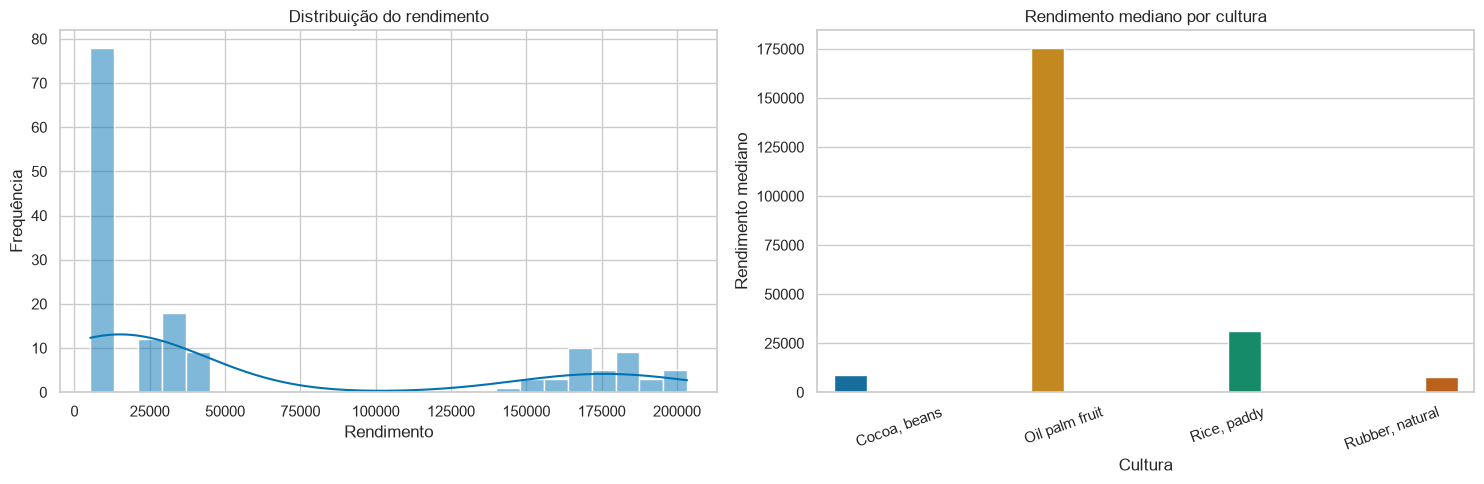

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
sns.histplot(data=df, x="yield", bins=25, kde=True, ax=axes[0])
axes[0].set(title="Distribuição do rendimento", xlabel="Rendimento", ylabel="Frequência")
sns.barplot(data=df, x="crop", y="yield", estimator=np.median, errorbar=None, hue="crop", legend=False, ax=axes[1])
axes[1].set(title="Rendimento mediano por cultura", xlabel="Cultura", ylabel="Rendimento mediano")
axes[1].tick_params(axis="x", rotation=20)
plt.tight_layout()
plt.show()

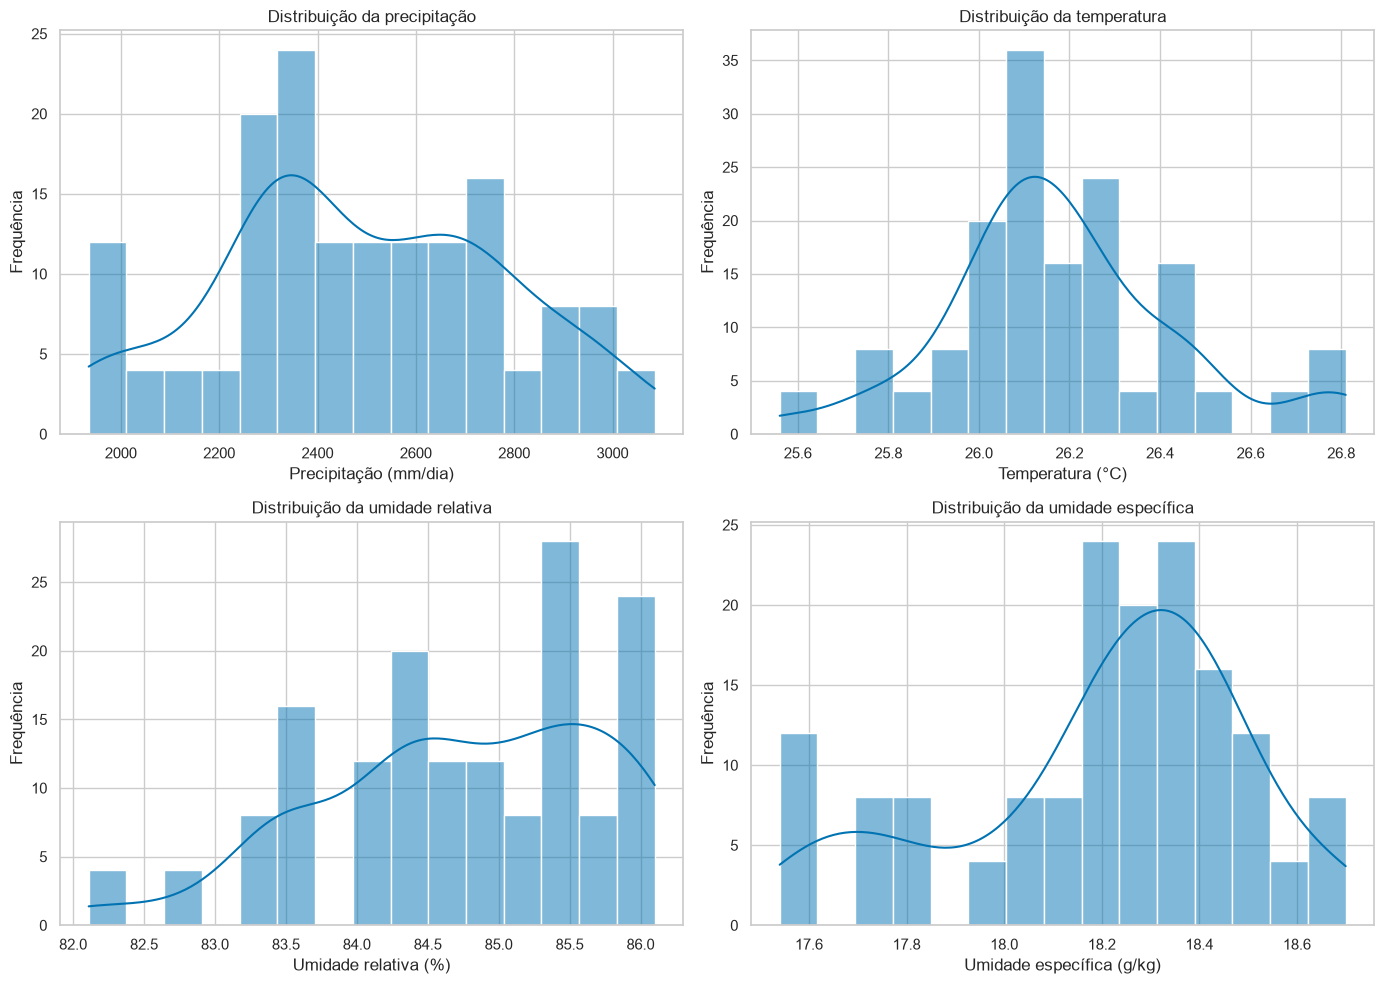

In [9]:
distribution_config = [
    ("precipitation_mm_day", "Distribuição da precipitação", "Precipitação (mm/dia)"),
    ("temperature_c", "Distribuição da temperatura", "Temperatura (°C)"),
    ("relative_humidity_pct", "Distribuição da umidade relativa", "Umidade relativa (%)"),
    ("specific_humidity_g_kg", "Distribuição da umidade específica", "Umidade específica (g/kg)"),
]
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
for ax, (column, title, xlabel) in zip(axes.flat, distribution_config):
    sns.histplot(data=df, x=column, bins=15, kde=True, ax=ax)
    ax.set(title=title, xlabel=xlabel, ylabel="Frequência")
plt.tight_layout()
plt.show()

**Leitura das distribuições:** o rendimento agregado é assimétrico à direita (assimetria de 1,14), principalmente pela escala muito superior do óleo de palma. A umidade específica e a relativa têm assimetria negativa, enquanto a temperatura apresenta assimetria positiva moderada. A precipitação é aproximadamente simétrica.

### 1.5 Relações entre ambiente, cultura e rendimento

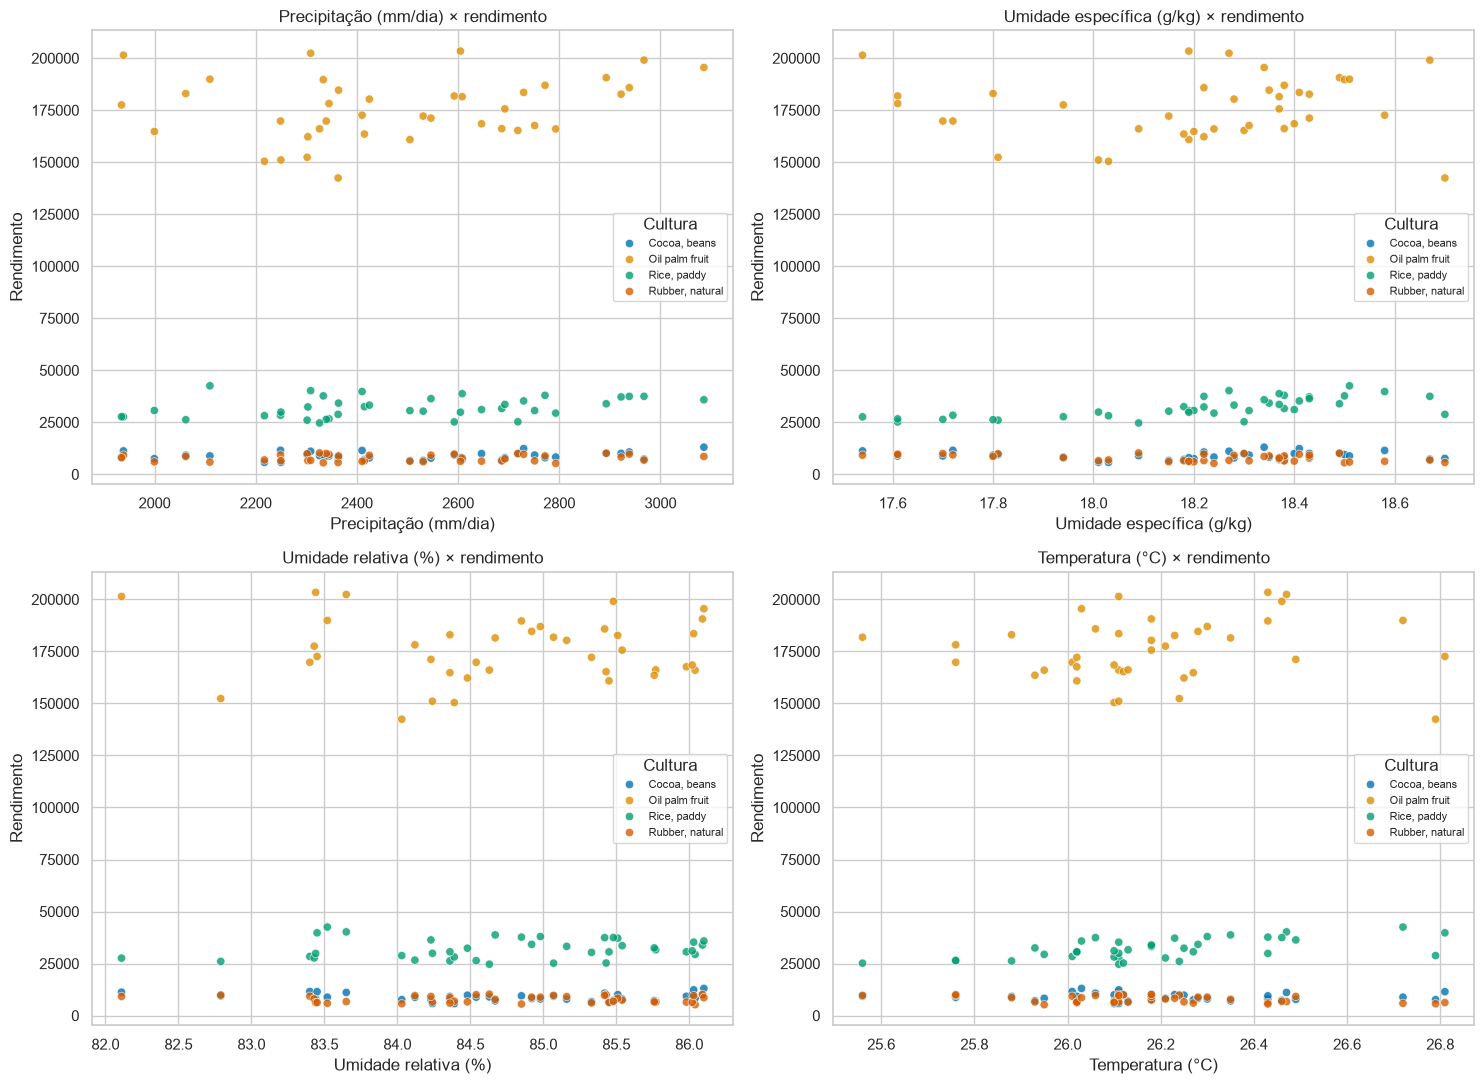

In [10]:
scatter_labels = {
    "precipitation_mm_day": "Precipitação (mm/dia)",
    "specific_humidity_g_kg": "Umidade específica (g/kg)",
    "relative_humidity_pct": "Umidade relativa (%)",
    "temperature_c": "Temperatura (°C)",
}
fig, axes = plt.subplots(2, 2, figsize=(15, 11))
for ax, column in zip(axes.flat, environmental_columns):
    sns.scatterplot(data=df, x=column, y="yield", hue="crop", alpha=0.8, ax=ax)
    ax.set(title=f"{scatter_labels[column]} × rendimento", xlabel=scatter_labels[column], ylabel="Rendimento")
    ax.legend(title="Cultura", fontsize=8)
plt.tight_layout()
plt.show()

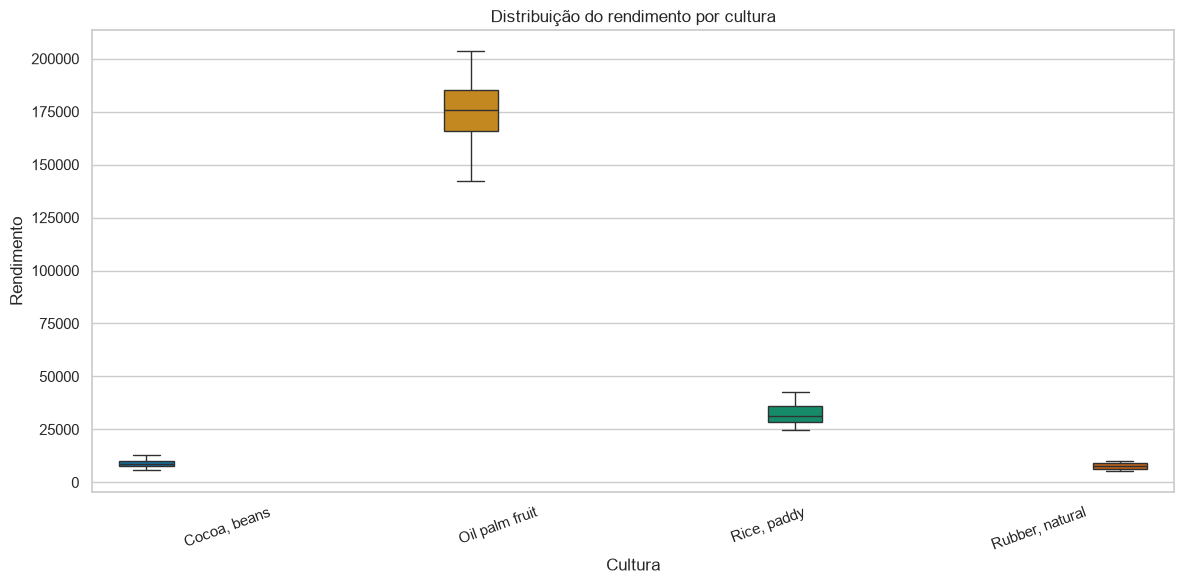

In [11]:
plt.figure(figsize=(12, 6))
sns.boxplot(data=df, x="crop", y="yield", hue="crop", legend=False)
plt.title("Distribuição do rendimento por cultura")
plt.xlabel("Cultura")
plt.ylabel("Rendimento")
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

**Leitura por cultura:** o óleo de palma possui a maior mediana de rendimento (175.629), seguido por arroz (31.101), cacau (8.848) e borracha natural (7.817). A grande diferença de escala entre as culturas domina a distribuição agregada. Os gráficos de dispersão mostram faixas claramente separadas por cultura, sem uma tendência linear ambiental evidente quando todas as culturas são reunidas.

### 1.6 Correlações e possíveis valores extremos

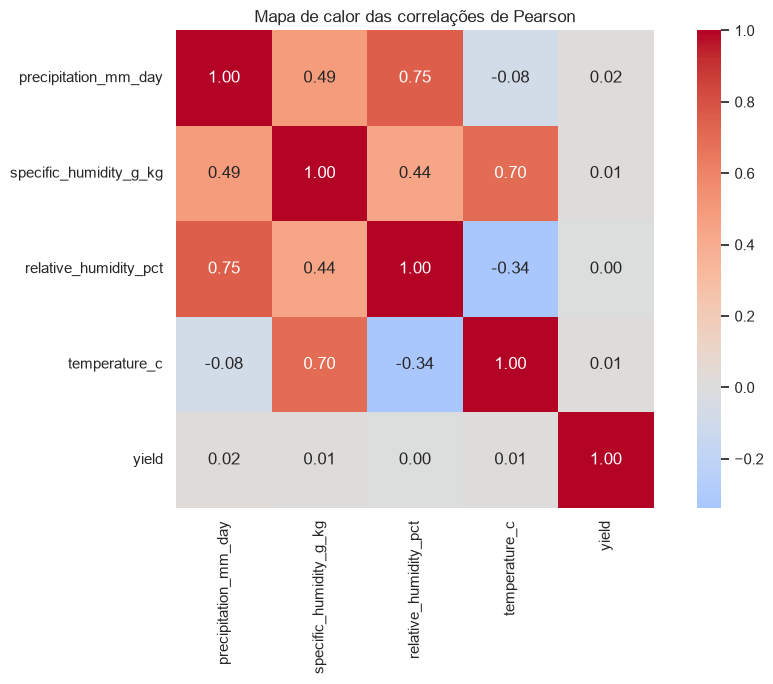

In [12]:
numeric_columns = environmental_columns + ["yield"]
correlation_matrix = df[numeric_columns].corr()
plt.figure(figsize=(10, 7))
sns.heatmap(correlation_matrix, annot=True, fmt=".2f", cmap="coolwarm", center=0, square=True)
plt.title("Mapa de calor das correlações de Pearson")
plt.tight_layout()
plt.show()

In [13]:
q1 = df[numeric_columns].quantile(0.25)
q3 = df[numeric_columns].quantile(0.75)
iqr = q3 - q1
iqr_outliers = ((df[numeric_columns] < (q1 - 1.5 * iqr)) | (df[numeric_columns] > (q3 + 1.5 * iqr))).sum()
display(pd.DataFrame({"assimetria": df[numeric_columns].skew(), "possíveis_outliers_iqr": iqr_outliers}).round(3))

,assimetria,possíveis_outliers_iqr
precipitation_mm_day,0.032,0
specific_humidity_g_kg,-0.702,0
relative_humidity_pct,-0.537,0
temperature_c,0.376,12
yield,1.136,35


**Síntese da EDA:** as correlações lineares agregadas entre rendimento e cada variável ambiental são próximas de zero (máximo absoluto de 0,019). Isso não demonstra ausência de influência: a cultura e a repetição das mesmas 39 condições ambientais para as quatro categorias podem mascarar relações específicas. Entre as variáveis ambientais, destacam-se precipitação × umidade relativa (0,75) e umidade específica × temperatura (0,70). Pelo critério IQR aplicado ao conjunto agregado aparecem 35 possíveis extremos de rendimento e 12 de temperatura, mas as diferenças estruturais entre culturas recomendam uma análise contextual antes de qualquer remoção. Correlação não implica causalidade.

## 2. Análise de Outliers

O método do intervalo interquartil (IQR) é aplicado inicialmente ao rendimento e, em seguida, às demais variáveis numéricas. Pontos sinalizados são candidatos à investigação, não erros automáticos.

### 2.1 Identificação global pelo método IQR

In [14]:
def iqr_summary(data, columns):
    q1 = data[columns].quantile(0.25)
    q3 = data[columns].quantile(0.75)
    iqr = q3 - q1
    lower_limit = q1 - 1.5 * iqr
    upper_limit = q3 + 1.5 * iqr
    mask = data[columns].lt(lower_limit) | data[columns].gt(upper_limit)

    summary = pd.DataFrame({
        "q1": q1,
        "q3": q3,
        "limite_inferior": lower_limit,
        "limite_superior": upper_limit,
        "total_outliers": mask.sum(),
        "percentual_outliers": (mask.mean() * 100).round(2),
    })
    return summary, mask


outlier_summary, outlier_mask = iqr_summary(df, numeric_columns)
display(outlier_summary.round(2))

,q1,q3,limite_inferior,limite_superior,total_outliers,percentual_outliers
precipitation_mm_day,2302.99,2718.08,1680.35,3340.72,0,0.00
specific_humidity_g_kg,18.03,18.40,17.48,18.95,0,0.00
relative_humidity_pct,84.12,85.51,82.04,87.60,0,0.00
temperature_c,26.02,26.30,25.60,26.72,12,7.69
yield,8327.75,67518.75,-80458.75,156305.25,35,22.44


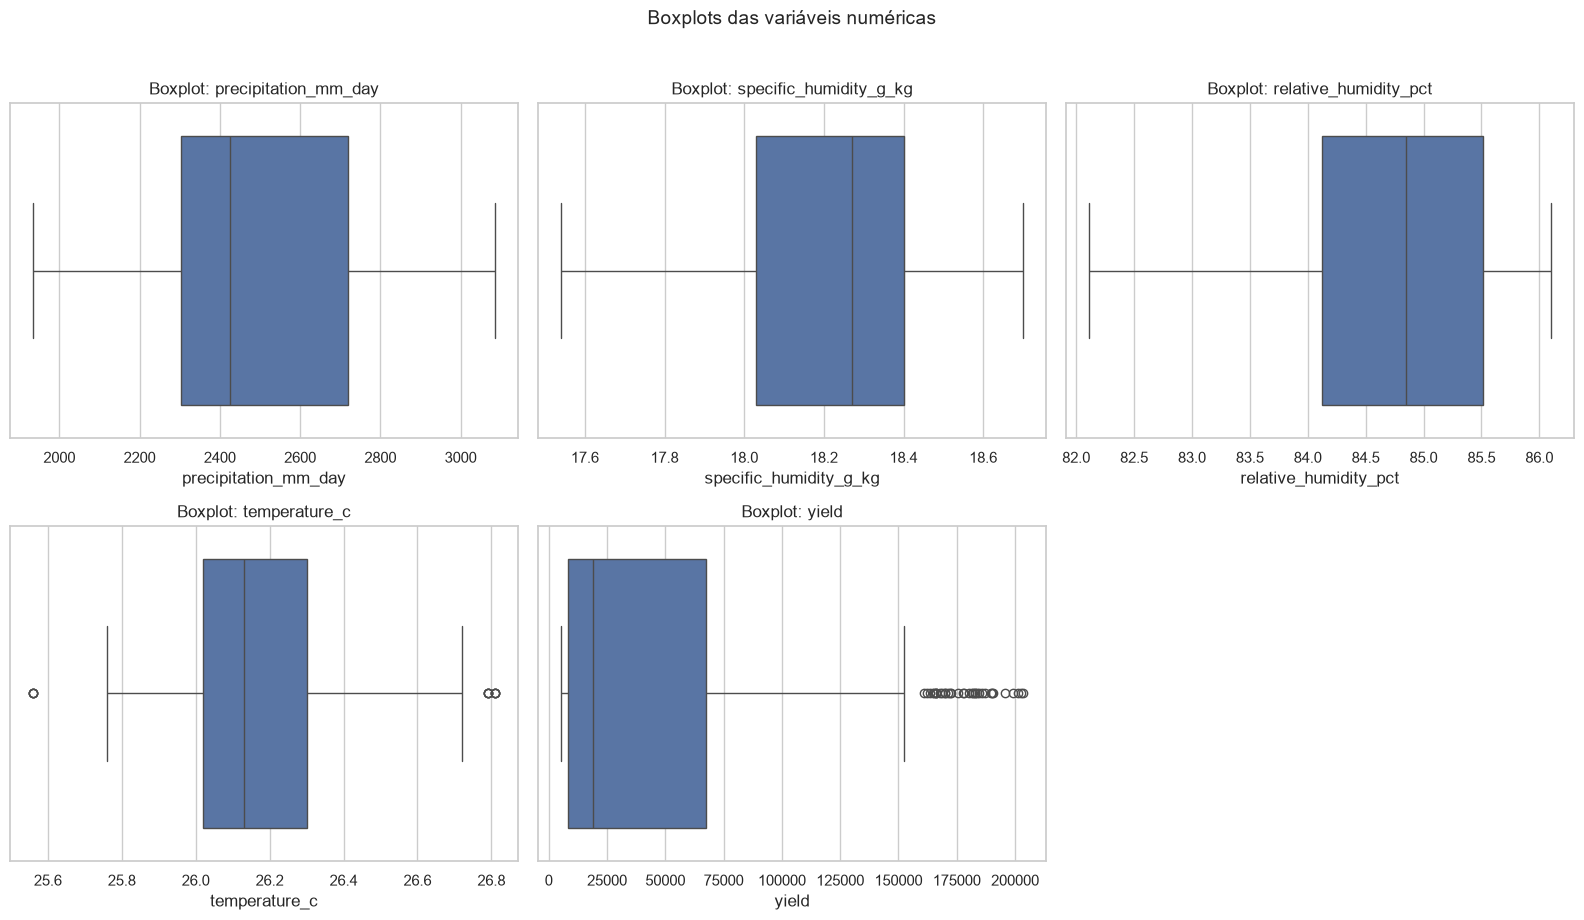

In [15]:
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
for ax, column in zip(axes.flat, numeric_columns):
    sns.boxplot(data=df, x=column, ax=ax, color="#4C72B0")
    ax.set_title(f"Boxplot: {column}")

axes.flat[-1].axis("off")
plt.suptitle("Boxplots das variáveis numéricas", y=1.02, fontsize=14)
plt.tight_layout()
plt.show()

In [16]:
yield_outlier_examples = df.loc[
    outlier_mask["yield"], ["crop", *environmental_columns, "yield"]
]
temperature_outlier_examples = df.loc[
    outlier_mask["temperature_c"], ["crop", "temperature_c", "yield"]
]

print("Distribuição dos outliers globais de rendimento por cultura:")
display(yield_outlier_examples["crop"].value_counts().rename("total").to_frame())
print("Exemplos de rendimentos sinalizados:")
display(yield_outlier_examples.head(10))
print("Linhas com temperatura sinalizada pelo IQR global:")
display(temperature_outlier_examples)

Distribuição dos outliers globais de rendimento por cultura:


,total
crop,
Oil palm fruit,35
"Cocoa, beans",0
"Rice, paddy",0
"Rubber, natural",0


Exemplos de rendimentos sinalizados:


,crop,precipitation_mm_day,specific_humidity_g_kg,relative_humidity_pct,temperature_c,yield
39,Oil palm fruit,2248.92,17.72,83.40,26.01,169783
40,Oil palm fruit,1938.42,17.54,82.11,26.11,201436
42,Oil palm fruit,2592.35,17.61,85.07,25.56,181826
43,Oil palm fruit,2344.72,17.61,84.12,25.76,178183
44,Oil palm fruit,2339.30,17.70,84.54,25.76,169781
45,Oil palm fruit,2326.09,18.09,84.63,26.11,166042
46,Oil palm fruit,2718.08,18.30,85.43,26.12,165262
47,Oil palm fruit,2061.61,17.80,84.36,25.88,183004
48,Oil palm fruit,1934.62,17.94,83.43,26.21,177543
51,Oil palm fruit,2530.96,18.15,85.33,26.02,172165


Linhas com temperatura sinalizada pelo IQR global:


,crop,temperature_c,yield
3,"Cocoa, beans",25.56,9321
17,"Cocoa, beans",26.79,7663
35,"Cocoa, beans",26.81,11487
42,Oil palm fruit,25.56,181826
56,Oil palm fruit,26.79,142425
74,Oil palm fruit,26.81,172601
81,"Rice, paddy",25.56,25187
95,"Rice, paddy",26.79,28829
113,"Rice, paddy",26.81,39775
120,"Rubber, natural",25.56,9718


### 2.2 Avaliação contextual por cultura

,crop,limite_inferior,limite_superior,total_outliers,percentual_outliers
0,"Cocoa, beans",4445.50,13201.50,0,0.0
1,Oil palm fruit,137198.75,214048.75,0,0.0
2,"Rice, paddy",16586.00,47806.00,0,0.0
3,"Rubber, natural",2086.25,13584.25,0,0.0


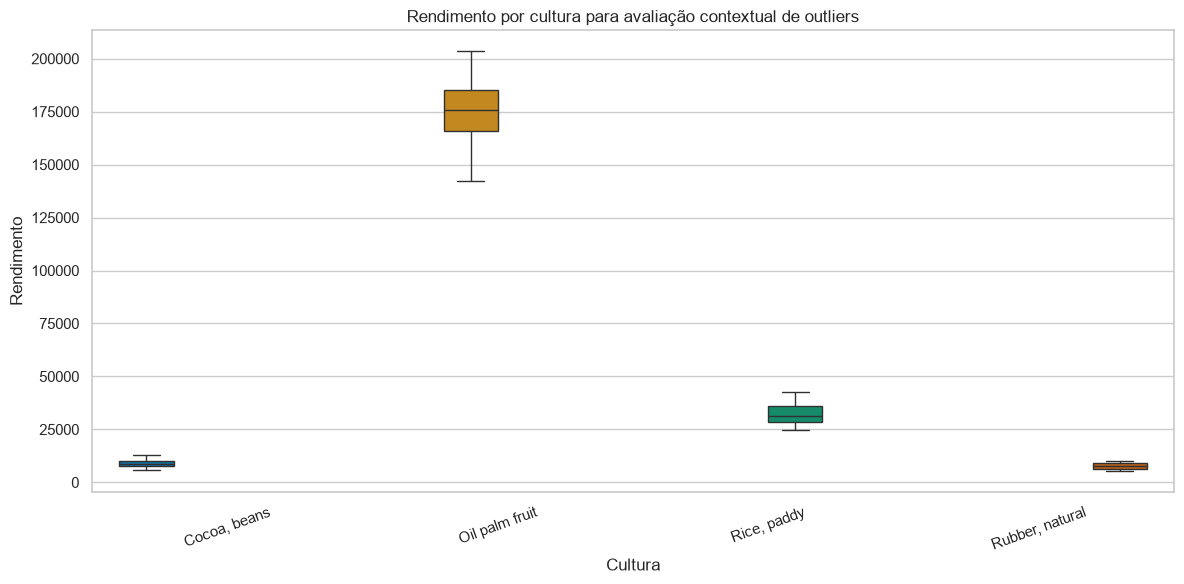

In [17]:
groupwise_outlier_rows = []
groupwise_masks = []

for crop, group in df.groupby("crop", observed=True):
    q1_crop = group["yield"].quantile(0.25)
    q3_crop = group["yield"].quantile(0.75)
    iqr_crop = q3_crop - q1_crop
    lower_crop = q1_crop - 1.5 * iqr_crop
    upper_crop = q3_crop + 1.5 * iqr_crop
    crop_mask = group["yield"].lt(lower_crop) | group["yield"].gt(upper_crop)
    groupwise_masks.append(crop_mask)
    groupwise_outlier_rows.append({
        "crop": crop,
        "limite_inferior": lower_crop,
        "limite_superior": upper_crop,
        "total_outliers": int(crop_mask.sum()),
        "percentual_outliers": round(crop_mask.mean() * 100, 2),
    })

groupwise_outlier_mask = pd.concat(groupwise_masks).sort_index()
groupwise_outlier_summary = pd.DataFrame(groupwise_outlier_rows)
display(groupwise_outlier_summary.round(2))

plt.figure(figsize=(12, 6))
sns.boxplot(data=df, x="crop", y="yield", hue="crop", legend=False)
plt.title("Rendimento por cultura para avaliação contextual de outliers")
plt.xlabel("Cultura")
plt.ylabel("Rendimento")
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

### 2.3 Decisão sobre os outliers

O IQR global sinaliza **35 rendimentos (22,44%)**, todos de óleo de palma. Entretanto, o IQR calculado dentro de cada cultura não sinaliza nenhum rendimento. Isso mostra que a diferença é estrutural entre culturas, e não evidência de erro.

A temperatura tem **12 registros sinalizados (7,69%)**, correspondentes às mesmas três condições ambientais repetidas nas quatro culturas. Todos permanecem entre **25,56 °C e 26,81 °C**, uma faixa estreita e fisicamente plausível neste conjunto.

Sem evidência de erro de medição, remover esses registros eliminaria grande parte de uma cultura válida e alteraria excessivamente a distribuição. Portanto, **nenhuma linha será removida**. A decisão preserva os 156 registros e permite que os modelos posteriores sejam avaliados sobre a diversidade real observada.

In [18]:
df_modeling = df.copy()
print(f"Registros antes da análise: {len(df)}")
print(f"Registros removidos: {len(df) - len(df_modeling)}")
print(f"Registros mantidos para modelagem: {len(df_modeling)}")

Registros antes da análise: 156
Registros removidos: 0
Registros mantidos para modelagem: 156


### 2.4 Preparação dos dados supervisionados

In [19]:
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler


categorical_features = ["crop"]
numeric_features = environmental_columns.copy()
feature_columns = categorical_features + numeric_features

# O identificador representa apenas o agrupamento das condições ambientais.
# Ele não será usado como variável preditora.
unique_scenarios = df_modeling[environmental_columns].drop_duplicates().reset_index(drop=True)
unique_scenarios["environment_scenario_id"] = np.arange(len(unique_scenarios))
modeling_with_scenario = df_modeling.merge(
    unique_scenarios,
    on=environmental_columns,
    how="left",
    validate="many_to_one",
)

X = modeling_with_scenario[feature_columns].copy()
y = modeling_with_scenario["yield"].copy()

scenario_ids = unique_scenarios["environment_scenario_id"].to_numpy()
train_scenario_ids, test_scenario_ids = train_test_split(
    scenario_ids,
    test_size=0.20,
    random_state=RANDOM_STATE,
)

train_mask = modeling_with_scenario["environment_scenario_id"].isin(train_scenario_ids)
test_mask = modeling_with_scenario["environment_scenario_id"].isin(test_scenario_ids)

X_train, X_test = X.loc[train_mask].copy(), X.loc[test_mask].copy()
y_train, y_test = y.loc[train_mask].copy(), y.loc[test_mask].copy()

print(f"X: {X.shape} | y: {y.shape}")
print(f"Treino: X={X_train.shape}, y={y_train.shape}")
print(f"Teste: X={X_test.shape}, y={y_test.shape}")
display(pd.DataFrame({
    "treino": X_train["crop"].value_counts().sort_index(),
    "teste": X_test["crop"].value_counts().sort_index(),
}))

X: (156, 5) | y: (156,)
Treino: X=(124, 5), y=(124,)
Teste: X=(32, 5), y=(32,)


,treino,teste
crop,,
"Cocoa, beans",31,8
Oil palm fruit,31,8
"Rice, paddy",31,8
"Rubber, natural",31,8


A separação é feita pelas 39 combinações ambientais, e não linha a linha. Assim, as quatro culturas observadas sob a mesma condição permanecem juntas em treino ou teste. Isso evita que uma condição ambiental idêntica apareça nos dois conjuntos. O resultado mantém 31 cenários (124 linhas) no treino e 8 cenários (32 linhas) no teste, com todas as culturas balanceadas.

In [20]:
shared_scenarios = set(train_scenario_ids) & set(test_scenario_ids)

assert "yield" not in X.columns
assert len(df_modeling) == 156
assert X_train.shape == (124, 5)
assert X_test.shape == (32, 5)
assert not shared_scenarios
assert X_train["crop"].value_counts().nunique() == 1
assert X_test["crop"].value_counts().nunique() == 1

print(f"Cenários compartilhados entre treino e teste: {len(shared_scenarios)}")
print("O rendimento está fora das features:", "yield" not in X.columns)
print("Validações do split concluídas com sucesso.")

Cenários compartilhados entre treino e teste: 0
O rendimento está fora das features: True
Validações do split concluídas com sucesso.


### 2.5 Pipeline de pré-processamento

In [21]:
preprocessor = ColumnTransformer(
    transformers=[
        (
            "categorical",
            OneHotEncoder(handle_unknown="ignore"),
            categorical_features,
        ),
        (
            "numeric",
            StandardScaler(),
            numeric_features,
        ),
    ],
    remainder="drop",
)

preprocessing_pipeline = Pipeline(
    steps=[("preprocessor", preprocessor)]
)

print(preprocessing_pipeline)
print("Pipeline definida, mas ainda não ajustada aos dados.")

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('categorical',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['crop']),
                                                 ('numeric', StandardScaler(),
                                                  ['precipitation_mm_day',
                                                   'specific_humidity_g_kg',
                                                   'relative_humidity_pct',
                                                   'temperature_c'])]))])
Pipeline definida, mas ainda não ajustada aos dados.


### 2.6 Prevenção de data leakage

- O rendimento real é exclusivamente o alvo `y` e não entra em `X`.
- O conjunto final de teste não participa do treinamento nem do ajuste das transformações.
- Cenários ambientais idênticos permanecem no mesmo conjunto.
- O `OneHotEncoder` e o `StandardScaler` estão dentro de uma `Pipeline`; nas próximas etapas, serão ajustados somente com `X_train` quando cada estimador for treinado.
- Não foi aplicado `fit_transform` ao dataset completo.
- Não foi adicionada imputação porque o dataset não possui valores ausentes.

Essas decisões mantêm o teste como uma estimativa independente da capacidade de generalização dos futuros modelos.

## 3. Machine Learning Não Supervisionado — Clusterização

Esta etapa busca tendências de produtividade por meio de agrupamentos. A matriz de clusterização inclui as quatro variáveis ambientais e o rendimento, todos padronizados. O rendimento é usado aqui apenas para análise exploratória não supervisionada; esta matriz é independente de `X`, `y`, do split e da Pipeline da regressão.

### 3.1 Preparação da matriz de clusterização

In [22]:
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score


clustering_features = environmental_columns + ["yield"]
X_clustering = df[clustering_features].copy()

# Scaler exclusivo da análise não supervisionada.
cluster_scaler = StandardScaler()
X_clustering_scaled = cluster_scaler.fit_transform(X_clustering)

print(f"Matriz original para clustering: {X_clustering.shape}")
print(f"Matriz padronizada: {X_clustering_scaled.shape}")
display(pd.DataFrame(X_clustering_scaled, columns=clustering_features).describe().round(3))

Matriz original para clustering: (156, 5)
Matriz padronizada: (156, 5)


,precipitation_mm_day,specific_humidity_g_kg,relative_humidity_pct,temperature_c,yield
count,156.000,156.000,156.000,156.000,156.000
mean,0.000,-0.000,0.000,0.000,-0.000
std,1.003,1.003,1.003,1.003,1.003
min,-1.913,-2.263,-2.646,-2.396,-0.725
25%,-0.636,-0.591,-0.622,-0.629,-0.681
50%,-0.215,0.228,0.113,-0.206,-0.531
75%,0.803,0.672,0.778,0.447,0.162
max,2.077,1.696,1.372,2.407,2.098


O ajuste global do `cluster_scaler` é apropriado somente nesta análise descritiva, que não estima desempenho preditivo. Ele não substitui nem altera o pré-processamento supervisionado, que continua sem ajuste global.

### 3.2 Escolha do número de clusters

In [23]:
k_evaluation = []

for k in range(2, 11):
    candidate_model = KMeans(
        n_clusters=k,
        random_state=RANDOM_STATE,
        n_init=20,
    )
    candidate_labels = candidate_model.fit_predict(X_clustering_scaled)
    k_evaluation.append({
        "k": k,
        "inertia": candidate_model.inertia_,
        "silhouette_score": silhouette_score(X_clustering_scaled, candidate_labels),
    })

k_results = pd.DataFrame(k_evaluation)
display(k_results.round(4))

,k,inertia,silhouette_score
0,2,535.9741,0.3165
1,3,383.1306,0.3330
2,4,303.3312,0.3628
3,5,259.0302,0.3741
4,6,219.7875,0.3536
5,7,189.9230,0.3852
6,8,166.1659,0.3907
7,9,151.6726,0.3731
8,10,135.9311,0.3589


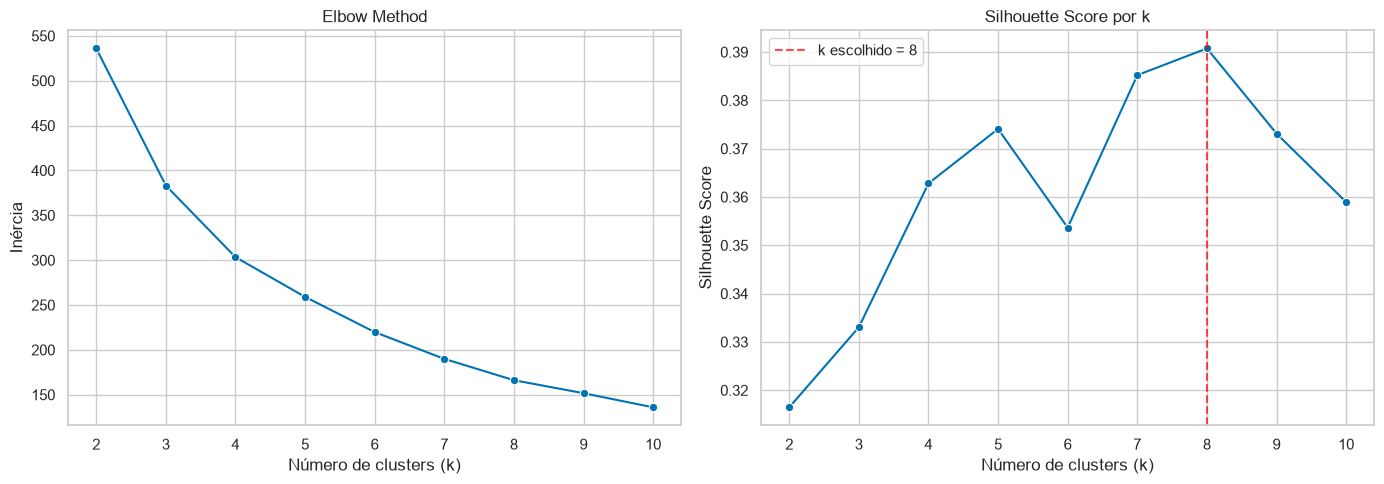

In [24]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.lineplot(data=k_results, x="k", y="inertia", marker="o", ax=axes[0])
axes[0].set(
    title="Elbow Method",
    xlabel="Número de clusters (k)",
    ylabel="Inércia",
    xticks=range(2, 11),
)

sns.lineplot(data=k_results, x="k", y="silhouette_score", marker="o", ax=axes[1])
axes[1].axvline(8, color="red", linestyle="--", alpha=0.7, label="k escolhido = 8")
axes[1].set(
    title="Silhouette Score por k",
    xlabel="Número de clusters (k)",
    ylabel="Silhouette Score",
    xticks=range(2, 11),
)
axes[1].legend()

plt.tight_layout()
plt.show()

A curva de inércia perde inclinação de forma mais evidente por volta de **4–5 clusters**, sugerindo um primeiro ponto de equilíbrio. O Silhouette Score, porém, atinge seu maior valor em **k=8 (0,391)**, contra 0,374 em k=5. Optou-se por `k=8` para privilegiar a separação observada e investigar subperfis ambientais. Essa escolha produz uma segmentação fina e deve ser interpretada com cautela devido ao tamanho reduzido da amostra.

### 3.3 Modelo final e perfis dos clusters

In [25]:
SELECTED_K = 8
kmeans_final = KMeans(
    n_clusters=SELECTED_K,
    random_state=RANDOM_STATE,
    n_init=20,
)
cluster_labels = kmeans_final.fit_predict(X_clustering_scaled)

df_clustered = df.copy()
df_clustered["cluster"] = cluster_labels

cluster_sizes = df_clustered["cluster"].value_counts().sort_index().rename("size")
cluster_means = df_clustered.groupby("cluster")[clustering_features].mean()
cluster_medians = df_clustered.groupby("cluster")[clustering_features].median()
cluster_profiles = pd.concat(
    {"mean": cluster_means, "median": cluster_medians},
    axis=1,
)

print("Tamanho dos clusters:")
display(cluster_sizes.to_frame())
print("Médias e medianas por cluster:")
display(cluster_profiles.round(2))

Tamanho dos clusters:


,size
cluster,
0,17
1,24
2,30
3,12
4,11
5,11
6,39
7,12


Médias e medianas por cluster:


mean                                               \
        precipitation_mm_day specific_humidity_g_kg relative_humidity_pct   
cluster                                                                     
0                    2733.52                  18.34                 85.65   
1                    2410.39                  18.44                 83.98   
2                    2333.41                  18.17                 84.87   
3                    2105.88                  17.75                 82.93   
4                    2232.22                  17.81                 83.92   
5                    2359.02                  18.39                 84.15   
6                    2814.98                  18.38                 85.72   
7                    2334.50                  17.68                 84.52   

                                               median                         \
        temperature_c      yield precipitation_mm_day specific_humidity_g_kg   
cluster                                                                        
0               26.12  177074.18              2729.53                  18.34   
1               26.56   17456.38              2386.46                  18.46   
2               26.13   15149.97              2344.86                  18.19   
3               26.14   15562.08              2093.67                  17.76   
4               25.99  171039.91              2249.70                  17.80   
5               26.48  178607.55              2362.80                  18.37   
6               26.14   17044.28              2771.73                  18.38   
7               25.74   14881.33              2342.01                  17.66   

                                                       
        relative_humidity_pct temperature_c     yield  
cluster                                                
0                       85.54         26.11  175629.0  
1                       83.84         26.48    9026.5  
2                       84.78         26.11    8541.5  
3                       83.10         26.16   10559.5  
4                       84.24         26.10  169783.0  
5                       84.23         26.43  181496.0  
6                       85.77         26.12   10010.0  
7                       84.45         25.76    9645.5

In [26]:
crop_cluster_counts = pd.crosstab(df_clustered["cluster"], df_clustered["crop"])
crop_cluster_percentages = pd.crosstab(
    df_clustered["cluster"],
    df_clustered["crop"],
    normalize="index",
) * 100

print("Quantidade de culturas por cluster:")
display(crop_cluster_counts)
print("Composição percentual de culturas por cluster:")
display(crop_cluster_percentages.round(1))

Quantidade de culturas por cluster:


crop,"Cocoa, beans",Oil palm fruit,"Rice, paddy","Rubber, natural"
cluster,,,,
0,0,17,0,0
1,8,0,8,8
2,10,0,10,10
3,4,0,4,4
4,0,11,0,0
5,0,11,0,0
6,13,0,13,13
7,4,0,4,4


Composição percentual de culturas por cluster:


crop,"Cocoa, beans",Oil palm fruit,"Rice, paddy","Rubber, natural"
cluster,,,,
0,0.0,100.0,0.0,0.0
1,33.3,0.0,33.3,33.3
2,33.3,0.0,33.3,33.3
3,33.3,0.0,33.3,33.3
4,0.0,100.0,0.0,0.0
5,0.0,100.0,0.0,0.0
6,33.3,0.0,33.3,33.3
7,33.3,0.0,33.3,33.3


In [27]:
profile_names = {
    0: "Alta produtividade com maior precipitação",
    1: "Rendimento baixo a intermediário em ambiente mais quente",
    2: "Rendimento baixo a intermediário em condições centrais",
    3: "Rendimento baixo a intermediário com menor precipitação",
    4: "Alta produtividade em ambiente menos úmido",
    5: "Alta produtividade com maior temperatura",
    6: "Rendimento baixo a intermediário com maior precipitação",
    7: "Rendimento baixo a intermediário com menor temperatura",
}

df_clustered["cluster_profile"] = df_clustered["cluster"].map(profile_names)
profile_summary = pd.DataFrame({
    "perfil": pd.Series(profile_names),
    "tamanho": cluster_sizes,
    "rendimento_médio": cluster_means["yield"],
    "rendimento_mediano": cluster_medians["yield"],
})
display(profile_summary.round(2))

,perfil,tamanho,rendimento_médio,rendimento_mediano
0,Alta produtividade com maior precipitação,17,177074.18,175629.0
1,Rendimento baixo a intermediário em ambiente m...,24,17456.38,9026.5
2,Rendimento baixo a intermediário em condições ...,30,15149.97,8541.5
3,Rendimento baixo a intermediário com menor pre...,12,15562.08,10559.5
4,Alta produtividade em ambiente menos úmido,11,171039.91,169783.0
5,Alta produtividade com maior temperatura,11,178607.55,181496.0
6,Rendimento baixo a intermediário com maior pre...,39,17044.28,10010.0
7,Rendimento baixo a intermediário com menor tem...,12,14881.33,9645.5


Os nomes são descritivos e foram definidos somente após observar médias, medianas e composição. Os clusters **0, 4 e 5** contêm exclusivamente óleo de palma e concentram rendimentos altos sob três perfis ambientais. Os clusters **1, 2, 3, 6 e 7** contêm, em proporções iguais dentro de cada grupo, cacau, arroz e borracha, diferenciando principalmente regimes de precipitação, umidade e temperatura. Os rótulos não representam relações causais.

### 3.4 Visualização dos perfis

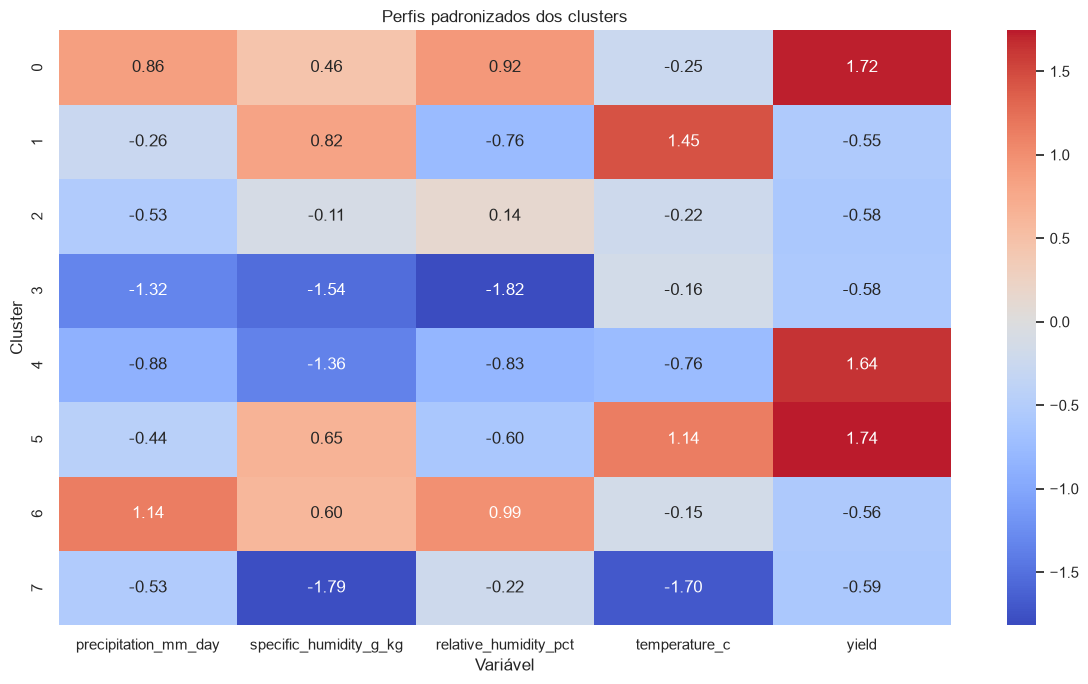

In [28]:
standardized_centroids = pd.DataFrame(
    kmeans_final.cluster_centers_,
    columns=clustering_features,
    index=pd.Index(range(SELECTED_K), name="cluster"),
)

plt.figure(figsize=(12, 7))
sns.heatmap(
    standardized_centroids,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
)
plt.title("Perfis padronizados dos clusters")
plt.xlabel("Variável")
plt.ylabel("Cluster")
plt.tight_layout()
plt.show()

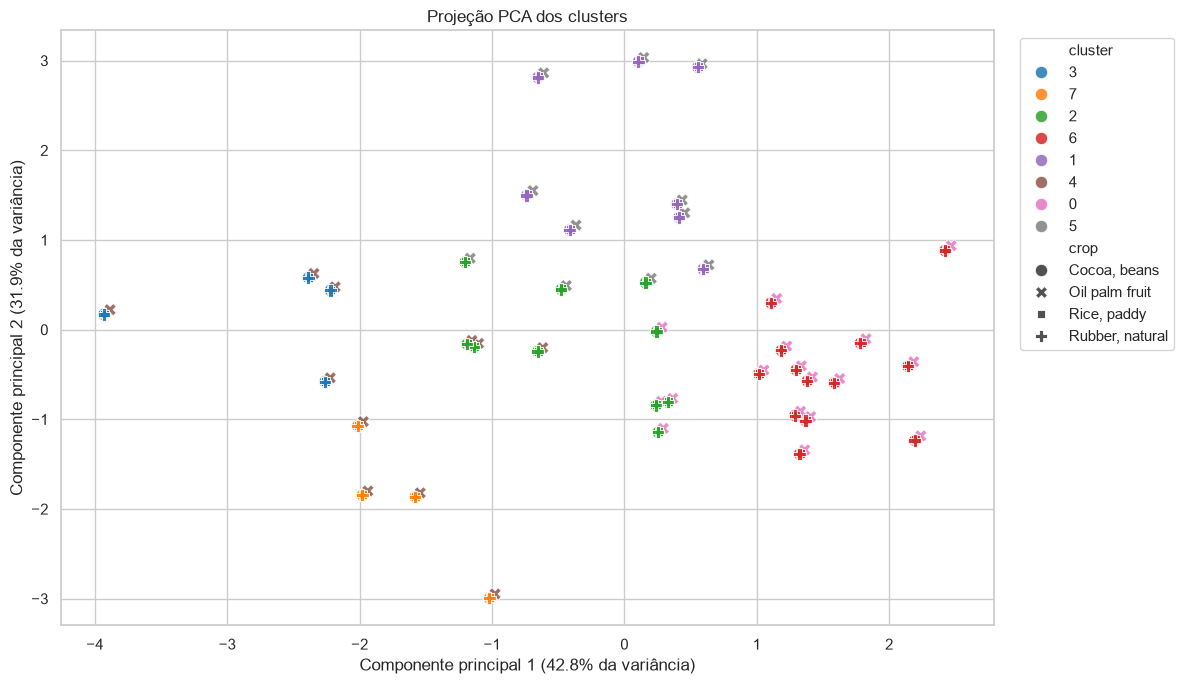

In [29]:
pca = PCA(n_components=2)
cluster_projection = pca.fit_transform(X_clustering_scaled)
projection_df = pd.DataFrame({
    "pc1": cluster_projection[:, 0],
    "pc2": cluster_projection[:, 1],
    "cluster": df_clustered["cluster"].astype(str),
    "crop": df_clustered["crop"].astype(str),
})

plt.figure(figsize=(12, 7))
sns.scatterplot(
    data=projection_df,
    x="pc1",
    y="pc2",
    hue="cluster",
    style="crop",
    palette="tab10",
    s=80,
    alpha=0.85,
)
plt.title("Projeção PCA dos clusters")
plt.xlabel(f"Componente principal 1 ({pca.explained_variance_ratio_[0]:.1%} da variância)")
plt.ylabel(f"Componente principal 2 ({pca.explained_variance_ratio_[1]:.1%} da variância)")
plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

A PCA foi aplicada somente para representar os cinco atributos em duas dimensões. O KMeans foi ajustado com todas as cinco variáveis padronizadas, não com a projeção.

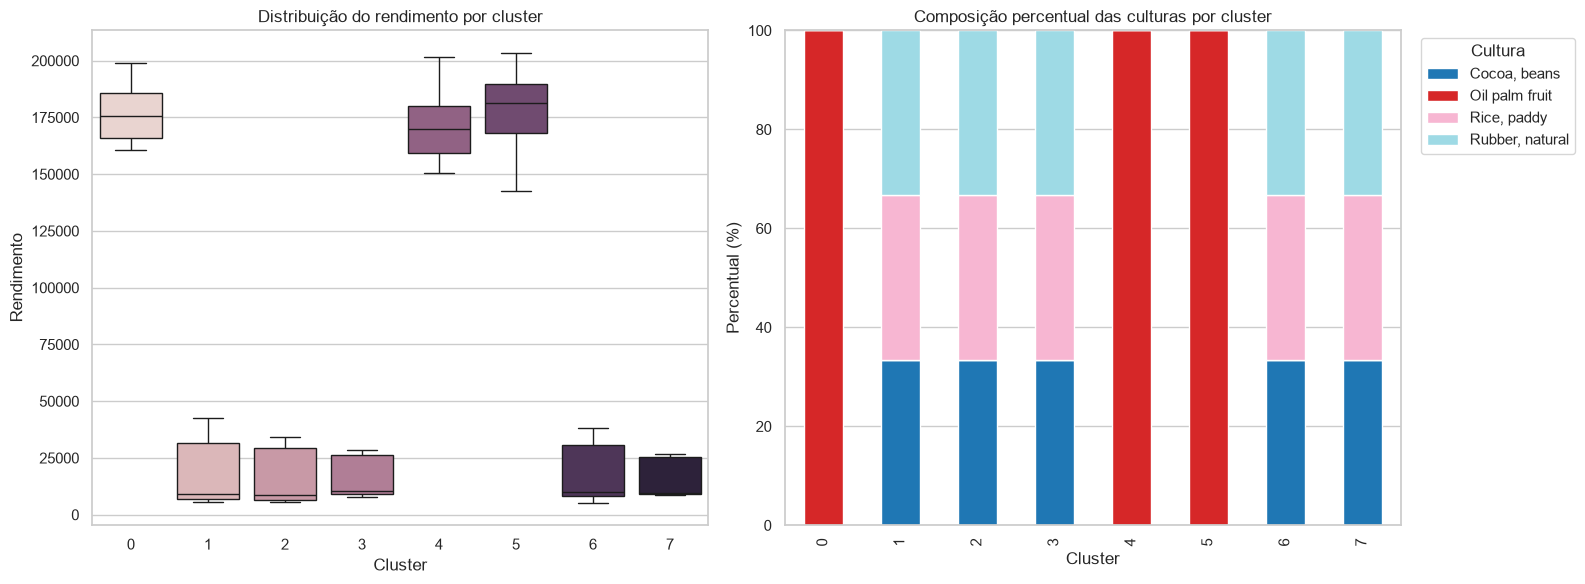

In [30]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.boxplot(data=df_clustered, x="cluster", y="yield", hue="cluster", legend=False, ax=axes[0])
axes[0].set(
    title="Distribuição do rendimento por cluster",
    xlabel="Cluster",
    ylabel="Rendimento",
)

crop_cluster_percentages.plot(kind="bar", stacked=True, ax=axes[1], colormap="tab20")
axes[1].set(
    title="Composição percentual das culturas por cluster",
    xlabel="Cluster",
    ylabel="Percentual (%)",
)
axes[1].legend(title="Cultura", bbox_to_anchor=(1.02, 1), loc="upper left")

plt.tight_layout()
plt.show()

### 3.5 Relação entre outliers e clusters

In [31]:
df_clustered["is_global_yield_outlier"] = outlier_mask["yield"].to_numpy()

outlier_cluster_counts = pd.crosstab(
    df_clustered.loc[df_clustered["is_global_yield_outlier"], "cluster"],
    df_clustered.loc[df_clustered["is_global_yield_outlier"], "crop"],
)
outlier_cluster_summary = (
    df_clustered.loc[df_clustered["is_global_yield_outlier"]]
    .groupby("cluster")
    .agg(
        total_outliers=("yield", "size"),
        rendimento_médio=("yield", "mean"),
        rendimento_mediano=("yield", "median"),
        precipitação_média=("precipitation_mm_day", "mean"),
        temperatura_média=("temperature_c", "mean"),
    )
)

print("Outliers globais de rendimento por cluster e cultura:")
display(outlier_cluster_counts)
display(outlier_cluster_summary.round(2))

Outliers globais de rendimento por cluster e cultura:


crop,Oil palm fruit
cluster,
0,17
4,8
5,10


,total_outliers,rendimento_médio,rendimento_mediano,precipitação_média,temperatura_média
cluster,,,,,
0,17,177074.18,175629.0,2733.52,26.12
4,8,178449.75,177863.0,2223.25,25.92
5,10,182225.80,183062.5,2358.65,26.45


Os **35 outliers globais de rendimento** estão distribuídos entre os clusters 0 (17), 4 (8) e 5 (10). Todos pertencem ao óleo de palma. Eles não se concentram em um único regime ambiental: aparecem em perfis de maior precipitação, menor umidade e maior temperatura. Portanto, representam principalmente a produtividade excepcional dessa cultura em relação às demais, e não uma anomalia ambiental única. Essa conclusão reforça a decisão anterior de manter os registros.

### 3.6 Limitações da clusterização

Os clusters descrevem padrões internos deste conjunto de 156 observações e dependem das variáveis e da padronização escolhidas. A inclusão do rendimento favorece a separação do óleo de palma pela diferença de escala entre culturas. Os grupos são úteis para exploração, mas não demonstram causalidade, não constituem classes agrícolas universais e precisam de validação em conjuntos maiores para generalização.

## 4. Machine Learning Supervisionado — Cinco Modelos de Regressão

Cinco algoritmos diferentes são treinados com o mesmo conjunto de treino e avaliados no mesmo holdout por cenário ambiental. Cada estimador recebe uma cópia do pré-processamento dentro de sua própria `Pipeline`, garantindo que codificação e escala sejam ajustadas somente com `X_train`.

### 4.1 Definição dos modelos e métricas

In [32]:
from sklearn.base import clone
from sklearn.ensemble import GradientBoostingRegressor, RandomForestRegressor
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor


regression_models = {
    "Regressão Linear": LinearRegression(),
    "Árvore de Decisão": DecisionTreeRegressor(random_state=RANDOM_STATE),
    "Random Forest": RandomForestRegressor(
        n_estimators=300,
        random_state=RANDOM_STATE,
        n_jobs=-1,
    ),
    "Gradient Boosting": GradientBoostingRegressor(random_state=RANDOM_STATE),
    "KNN": KNeighborsRegressor(n_neighbors=5),
}

print(f"Modelos definidos: {len(regression_models)}")
for model_name, estimator in regression_models.items():
    print(f"- {model_name}: {estimator.__class__.__name__}")

Modelos definidos: 5
- Regressão Linear: LinearRegression
- Árvore de Decisão: DecisionTreeRegressor
- Random Forest: RandomForestRegressor
- Gradient Boosting: GradientBoostingRegressor
- KNN: KNeighborsRegressor


Os hiperparâmetros são intencionalmente conservadores nesta comparação inicial. Árvores e ensembles recebem `random_state=42`; o Random Forest usa 300 árvores para reduzir variação. O KNN se beneficia do `StandardScaler` já incluído no pré-processamento.

In [33]:
fitted_models = {}
test_predictions = {}
model_metrics = []

for model_name, estimator in regression_models.items():
    model_pipeline = Pipeline(
        steps=[
            ("preprocessor", clone(preprocessor)),
            ("model", clone(estimator)),
        ]
    )

    # Todo ajuste, inclusive encoder e scaler, acontece somente no treino.
    model_pipeline.fit(X_train, y_train)
    y_pred_test = model_pipeline.predict(X_test)
    y_pred_train = model_pipeline.predict(X_train)

    mse_test = mean_squared_error(y_test, y_pred_test)
    model_metrics.append({
        "Modelo": model_name,
        "MAE": mean_absolute_error(y_test, y_pred_test),
        "MSE": mse_test,
        "RMSE": np.sqrt(mse_test),
        "R² Teste": r2_score(y_test, y_pred_test),
        "R² Treino": r2_score(y_train, y_pred_train),
    })
    fitted_models[model_name] = model_pipeline
    test_predictions[model_name] = y_pred_test

model_results = (
    pd.DataFrame(model_metrics)
    .sort_values("RMSE")
    .reset_index(drop=True)
)
display(model_results.style.format({
    "MAE": "{:,.2f}",
    "MSE": "{:,.2f}",
    "RMSE": "{:,.2f}",
    "R² Teste": "{:.4f}",
    "R² Treino": "{:.4f}",
}))

,Modelo,MAE,MSE,RMSE,R² Teste,R² Treino
0,Gradient Boosting,"4,857.06","61,179,457.30","7,821.73",0.9887,0.9996
1,Regressão Linear,"5,857.98","73,984,696.73","8,601.44",0.9863,0.9886
2,Random Forest,"5,864.07","98,893,292.59","9,944.51",0.9817,0.9985
3,Árvore de Decisão,"7,923.00","200,147,575.94","14,147.35",0.9629,1.0000
4,KNN,"14,353.31","534,979,581.04","23,129.63",0.9009,0.8421


Todas as métricas são calculadas a partir das previsões reais do holdout:

- **MAE:** erro absoluto médio, na unidade do rendimento.
- **MSE:** erro quadrático médio, que penaliza mais fortemente erros grandes.
- **RMSE:** raiz do MSE, novamente na unidade do rendimento.
- **R²:** proporção da variação explicada; também é exibido no treino para apoiar a análise posterior de overfitting.

O conjunto de teste foi usado somente após o ajuste de cada Pipeline.

### 4.2 Comparação visual dos modelos

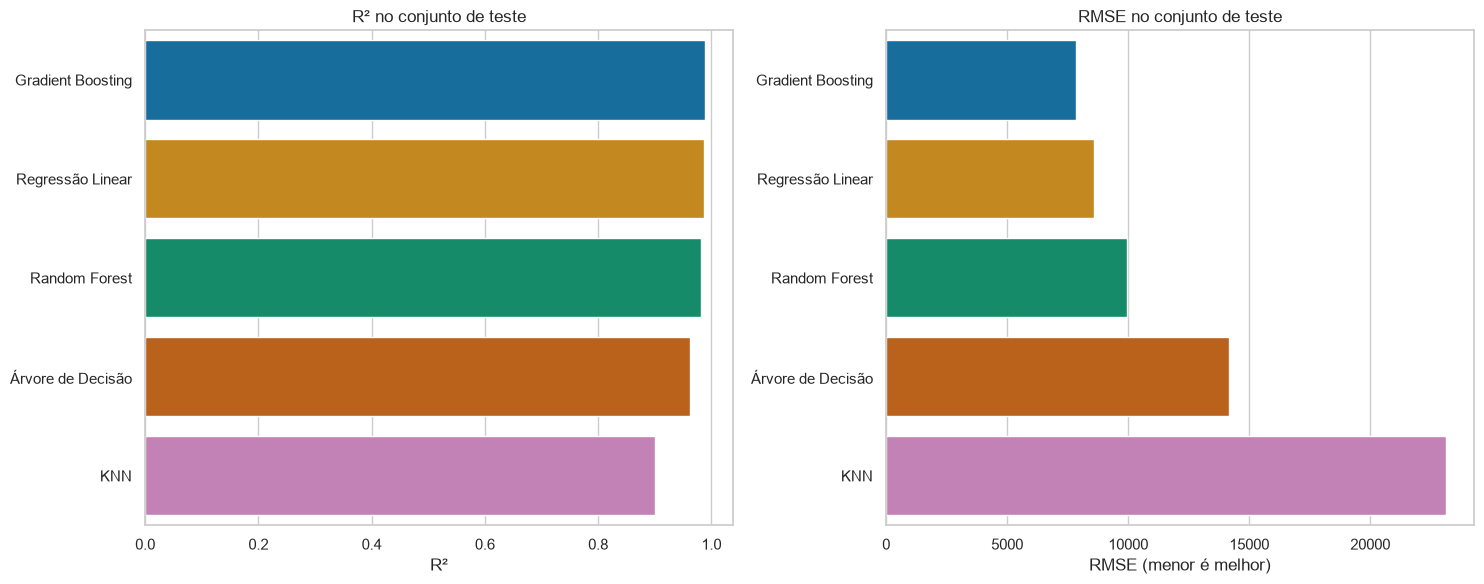

In [34]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

r2_order = model_results.sort_values("R² Teste", ascending=False)
sns.barplot(
    data=r2_order,
    x="R² Teste",
    y="Modelo",
    hue="Modelo",
    legend=False,
    ax=axes[0],
)
axes[0].set_title("R² no conjunto de teste")
axes[0].set_xlabel("R²")
axes[0].set_ylabel("")

rmse_order = model_results.sort_values("RMSE")
sns.barplot(
    data=rmse_order,
    x="RMSE",
    y="Modelo",
    hue="Modelo",
    legend=False,
    ax=axes[1],
)
axes[1].set_title("RMSE no conjunto de teste")
axes[1].set_xlabel("RMSE (menor é melhor)")
axes[1].set_ylabel("")

plt.tight_layout()
plt.show()

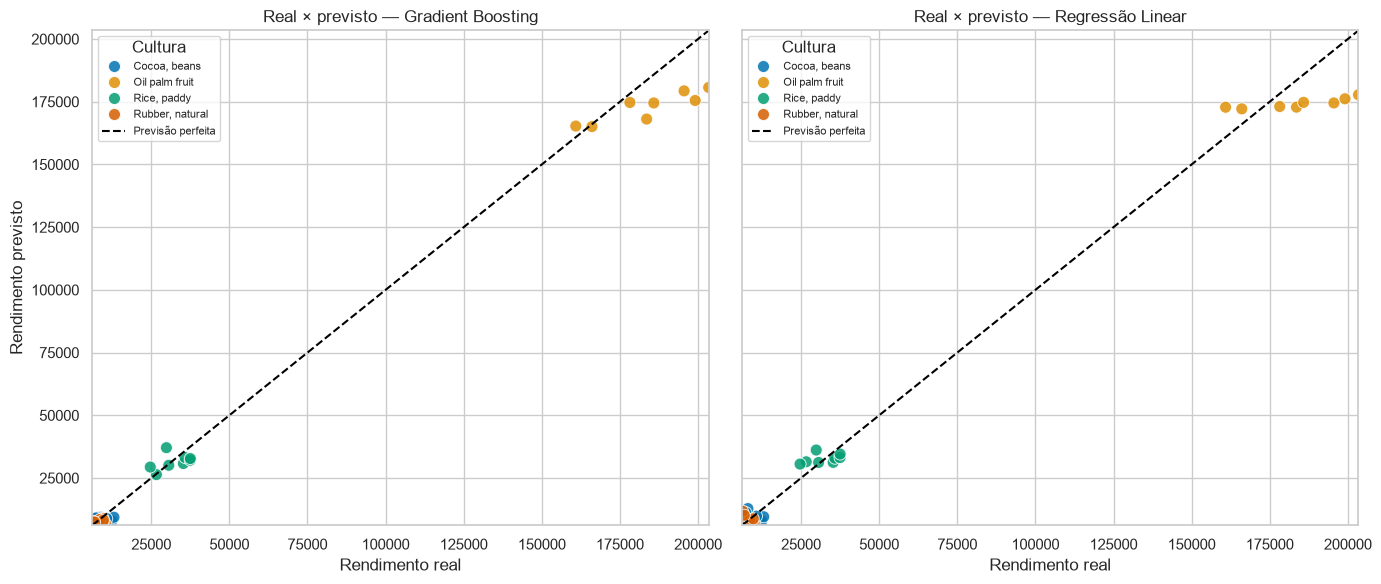

Dois melhores modelos preliminares por RMSE: ['Gradient Boosting', 'Regressão Linear']


In [35]:
top_models = model_results.nsmallest(2, "RMSE")["Modelo"].tolist()
fig, axes = plt.subplots(1, 2, figsize=(14, 6), sharex=True, sharey=True)

prediction_limits = [
    min(y_test.min(), *(test_predictions[name].min() for name in top_models)),
    max(y_test.max(), *(test_predictions[name].max() for name in top_models)),
]

for ax, model_name in zip(axes, top_models):
    sns.scatterplot(
        x=y_test.to_numpy(),
        y=test_predictions[model_name],
        hue=X_test["crop"].astype(str).to_numpy(),
        s=75,
        alpha=0.85,
        ax=ax,
    )
    ax.plot(prediction_limits, prediction_limits, "--", color="black", label="Previsão perfeita")
    ax.set(
        title=f"Real × previsto — {model_name}",
        xlabel="Rendimento real",
        ylabel="Rendimento previsto",
        xlim=prediction_limits,
        ylim=prediction_limits,
    )
    ax.legend(title="Cultura", fontsize=8)

plt.tight_layout()
plt.show()
print("Dois melhores modelos preliminares por RMSE:", top_models)

### 4.3 Resíduos do melhor resultado no holdout

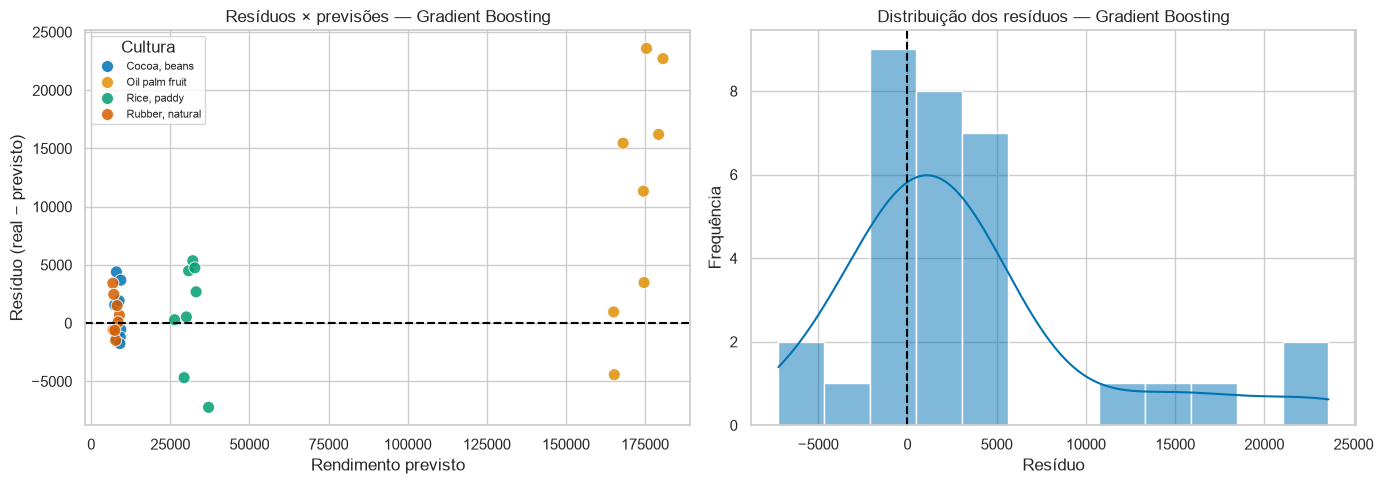

In [36]:
best_holdout_model_name = model_results.iloc[0]["Modelo"]
best_holdout_predictions = test_predictions[best_holdout_model_name]
best_holdout_residuals = y_test.to_numpy() - best_holdout_predictions

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.scatterplot(
    x=best_holdout_predictions,
    y=best_holdout_residuals,
    hue=X_test["crop"].astype(str).to_numpy(),
    s=75,
    alpha=0.85,
    ax=axes[0],
)
axes[0].axhline(0, color="black", linestyle="--")
axes[0].set(
    title=f"Resíduos × previsões — {best_holdout_model_name}",
    xlabel="Rendimento previsto",
    ylabel="Resíduo (real − previsto)",
)
axes[0].legend(title="Cultura", fontsize=8)

sns.histplot(best_holdout_residuals, bins=12, kde=True, ax=axes[1])
axes[1].axvline(0, color="black", linestyle="--")
axes[1].set(
    title=f"Distribuição dos resíduos — {best_holdout_model_name}",
    xlabel="Resíduo",
    ylabel="Frequência",
)

plt.tight_layout()
plt.show()

### 4.4 Resultado preliminar

No holdout, o **Gradient Boosting** apresentou o menor RMSE (aproximadamente 7.821,73), o menor MAE (4.857,06) e R² de 0,9887. A **Regressão Linear** ficou em segundo lugar por RMSE, com R² de 0,9863, apesar de sua estrutura muito mais simples.

A Árvore de Decisão e o Random Forest alcançaram R² de treino muito próximos de 1, enquanto o desempenho no teste foi inferior ao do Gradient Boosting, um indício que merece investigação de overfitting. O KNN obteve o resultado mais fraco e R² de treino menor que o de teste, sugerindo possível underfitting com a configuração inicial.

Esses resultados são apenas uma comparação preliminar no holdout. A escolha do modelo final será feita depois da validação cruzada, considerando erro, estabilidade, complexidade e diferença entre treino e teste — não apenas o maior R².

## 5. Validação Cruzada e Comparação dos Modelos

A comparação anterior usou um único holdout. Nesta seção, os cinco modelos são avaliados em cinco folds construídos apenas dentro do conjunto de treino. A Pipeline completa participa de cada fold, impedindo que encoder e scaler aprendam com a validação.

### 5.1 KFold agrupado por cenário ambiental

In [37]:
from sklearn.model_selection import GridSearchCV, KFold, cross_validate


# Recupera o cenário de cada linha do treino na mesma ordem usada por X_train.
train_scenario_series = (
    modeling_with_scenario.loc[train_mask, "environment_scenario_id"]
    .reset_index(drop=True)
)
unique_train_scenarios = np.sort(train_scenario_series.unique())

scenario_kfold = KFold(
    n_splits=5,
    shuffle=True,
    random_state=RANDOM_STATE,
)

# O KFold divide os 31 cenários; os índices abaixo expandem cada fold
# para as quatro linhas/culturas pertencentes a cada cenário.
cv_splits = []
fold_summary = []
for fold_number, (scenario_train_idx, scenario_validation_idx) in enumerate(
    scenario_kfold.split(unique_train_scenarios), start=1
):
    fold_train_scenarios = unique_train_scenarios[scenario_train_idx]
    fold_validation_scenarios = unique_train_scenarios[scenario_validation_idx]
    row_train_idx = np.flatnonzero(
        train_scenario_series.isin(fold_train_scenarios).to_numpy()
    )
    row_validation_idx = np.flatnonzero(
        train_scenario_series.isin(fold_validation_scenarios).to_numpy()
    )
    cv_splits.append((row_train_idx, row_validation_idx))
    fold_summary.append({
        "fold": fold_number,
        "cenários_treino": len(fold_train_scenarios),
        "cenários_validação": len(fold_validation_scenarios),
        "linhas_treino": len(row_train_idx),
        "linhas_validação": len(row_validation_idx),
        "cenários_compartilhados": len(
            set(fold_train_scenarios) & set(fold_validation_scenarios)
        ),
    })

fold_summary = pd.DataFrame(fold_summary)
display(fold_summary)
assert len(cv_splits) == 5
assert fold_summary["cenários_compartilhados"].eq(0).all()

,fold,cenários_treino,cenários_validação,linhas_treino,linhas_validação,cenários_compartilhados
0,1,24,7,96,28,0
1,2,25,6,100,24,0
2,3,25,6,100,24,0
3,4,25,6,100,24,0
4,5,25,6,100,24,0


O `KFold(n_splits=5, shuffle=True, random_state=42)` é aplicado aos cenários ambientais, não diretamente às linhas. Dessa forma, cada condição e suas quatro culturas permanecem juntas em treino ou validação. O holdout final de 32 linhas continua completamente isolado desta etapa.

### 5.2 Validação cruzada dos cinco modelos

In [38]:
cv_scoring = {
    "mae": "neg_mean_absolute_error",
    "rmse": "neg_root_mean_squared_error",
    "r2": "r2",
}

cv_metrics = []
cv_fold_results = []

for model_name, estimator in regression_models.items():
    cv_pipeline = Pipeline(
        steps=[
            ("preprocessor", clone(preprocessor)),
            ("model", clone(estimator)),
        ]
    )
    scores = cross_validate(
        cv_pipeline,
        X_train.reset_index(drop=True),
        y_train.reset_index(drop=True),
        cv=cv_splits,
        scoring=cv_scoring,
        return_train_score=False,
    )

    mae_scores = -scores["test_mae"]
    rmse_scores = -scores["test_rmse"]
    r2_scores = scores["test_r2"]
    holdout_row = model_results.loc[model_results["Modelo"] == model_name].iloc[0]

    cv_metrics.append({
        "Modelo": model_name,
        "MAE CV": mae_scores.mean(),
        "Desvio MAE": mae_scores.std(),
        "RMSE CV": rmse_scores.mean(),
        "Desvio RMSE": rmse_scores.std(),
        "R² CV": r2_scores.mean(),
        "Desvio R²": r2_scores.std(),
        "R² Teste": holdout_row["R² Teste"],
        "R² Treino": holdout_row["R² Treino"],
        "RMSE Teste": holdout_row["RMSE"],
    })

    for fold, (mae, rmse, r2) in enumerate(
        zip(mae_scores, rmse_scores, r2_scores), start=1
    ):
        cv_fold_results.append({
            "Modelo": model_name,
            "Fold": fold,
            "MAE": mae,
            "RMSE": rmse,
            "R²": r2,
        })

cv_results = (
    pd.DataFrame(cv_metrics)
    .sort_values("RMSE CV")
    .reset_index(drop=True)
)
cv_fold_results = pd.DataFrame(cv_fold_results)

display(cv_results.style.format({
    "MAE CV": "{:,.2f}",
    "Desvio MAE": "{:,.2f}",
    "RMSE CV": "{:,.2f}",
    "Desvio RMSE": "{:,.2f}",
    "R² CV": "{:.4f}",
    "Desvio R²": "{:.4f}",
    "R² Teste": "{:.4f}",
    "R² Treino": "{:.4f}",
    "RMSE Teste": "{:,.2f}",
}))

,Modelo,MAE CV,Desvio MAE,RMSE CV,Desvio RMSE,R² CV,Desvio R²,R² Teste,R² Treino,RMSE Teste
0,Random Forest,"4,000.56","1,023.25","7,263.49","2,620.25",0.9876,0.0074,0.9817,0.9985,"9,944.51"
1,Gradient Boosting,"4,143.92",808.93,"7,798.92","1,642.15",0.9867,0.0057,0.9887,0.9996,"7,821.73"
2,Regressão Linear,"5,124.91",349.82,"8,052.99","1,383.95",0.9861,0.0044,0.9863,0.9886,"8,601.44"
3,Árvore de Decisão,"4,702.92",767.12,"8,820.68","1,934.70",0.9828,0.0072,0.9629,1.0000,"14,147.35"
4,KNN,"12,677.51","5,760.08","21,986.82","10,124.76",0.8811,0.0832,0.9009,0.8421,"23,129.63"


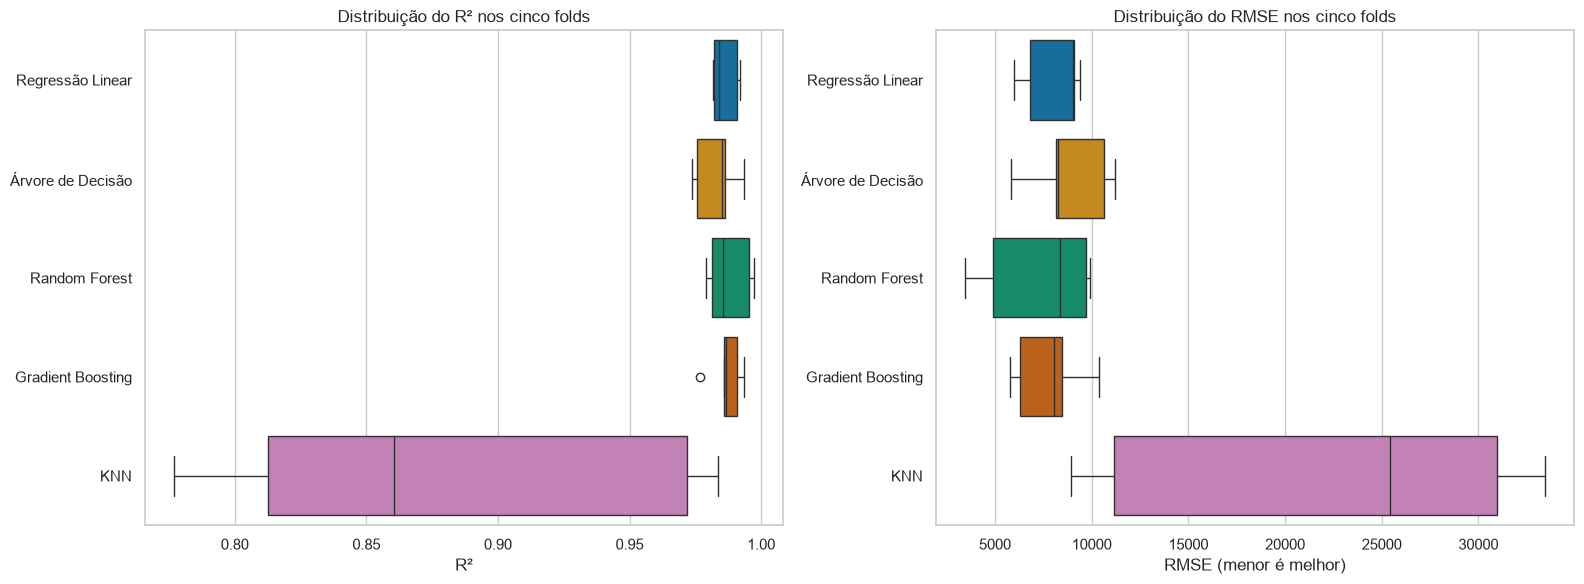

In [39]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.boxplot(
    data=cv_fold_results,
    x="R²",
    y="Modelo",
    hue="Modelo",
    legend=False,
    ax=axes[0],
)
axes[0].set_title("Distribuição do R² nos cinco folds")
axes[0].set_xlabel("R²")
axes[0].set_ylabel("")

sns.boxplot(
    data=cv_fold_results,
    x="RMSE",
    y="Modelo",
    hue="Modelo",
    legend=False,
    ax=axes[1],
)
axes[1].set_title("Distribuição do RMSE nos cinco folds")
axes[1].set_xlabel("RMSE (menor é melhor)")
axes[1].set_ylabel("")

plt.tight_layout()
plt.show()

Na configuração inicial, o **Random Forest** alcançou o menor RMSE médio de CV (7.263,49) e o maior R² médio (0,9876), mas apresentou maior dispersão e diferença relevante entre treino e teste. O **Gradient Boosting** teve RMSE médio de 7.798,92, R² médio de 0,9867 e melhor holdout. A **Regressão Linear** foi a mais estável em R² (desvio de 0,0044), com desempenho competitivo e menor complexidade.

A Árvore de Decisão mostra overfitting claro: R² de treino igual a 1 e queda para 0,9629 no teste. O KNN apresenta os maiores erros, maior instabilidade e R² de treino baixo, indicando underfitting na configuração inicial.

### 5.3 Tuning dos dois melhores modelos

In [40]:
tuning_grids = {
    "Random Forest": {
        "model__n_estimators": [200, 300],
        "model__max_depth": [None, 5, 10],
        "model__min_samples_leaf": [1, 2, 4],
    },
    "Gradient Boosting": {
        "model__n_estimators": [100, 200],
        "model__learning_rate": [0.03, 0.05, 0.1],
        "model__max_depth": [2, 3],
        "model__min_samples_leaf": [1, 3],
    },
}

tuning_searches = {}
tuning_metrics = []

for model_name, parameter_grid in tuning_grids.items():
    tuning_pipeline = Pipeline(
        steps=[
            ("preprocessor", clone(preprocessor)),
            ("model", clone(regression_models[model_name])),
        ]
    )
    search = GridSearchCV(
        estimator=tuning_pipeline,
        param_grid=parameter_grid,
        scoring="neg_root_mean_squared_error",
        cv=cv_splits,
        n_jobs=1,
        refit=True,
    )
    search.fit(X_train.reset_index(drop=True), y_train.reset_index(drop=True))

    tuned_test_prediction = search.predict(X_test)
    tuned_train_prediction = search.predict(X_train)
    tuned_test_mse = mean_squared_error(y_test, tuned_test_prediction)

    tuning_searches[model_name] = search
    tuning_metrics.append({
        "Modelo": model_name,
        "Melhor RMSE CV": -search.best_score_,
        "MAE Teste": mean_absolute_error(y_test, tuned_test_prediction),
        "RMSE Teste": np.sqrt(tuned_test_mse),
        "R² Teste": r2_score(y_test, tuned_test_prediction),
        "R² Treino": r2_score(y_train, tuned_train_prediction),
        "Melhores parâmetros": search.best_params_,
    })

tuning_results = pd.DataFrame(tuning_metrics).sort_values("Melhor RMSE CV")
display(tuning_results.style.format({
    "Melhor RMSE CV": "{:,.2f}",
    "MAE Teste": "{:,.2f}",
    "RMSE Teste": "{:,.2f}",
    "R² Teste": "{:.4f}",
    "R² Treino": "{:.4f}",
}))

,Modelo,Melhor RMSE CV,MAE Teste,RMSE Teste,R² Teste,R² Treino,Melhores parâmetros
1,Gradient Boosting,"7,254.12","4,953.26","7,920.47",0.9884,0.9987,"{'model__learning_rate': 0.05, 'model__max_depth': 3, 'model__min_samples_leaf': 3, 'model__n_estimators': 200}"
0,Random Forest,"7,260.52","5,751.52","9,710.97",0.9825,0.9977,"{'model__max_depth': 5, 'model__min_samples_leaf': 1, 'model__n_estimators': 300}"


In [41]:
for model_name, search in tuning_searches.items():
    print(f"{model_name}: {search.best_params_}")

Random Forest: {'model__max_depth': 5, 'model__min_samples_leaf': 1, 'model__n_estimators': 300}
Gradient Boosting: {'model__learning_rate': 0.05, 'model__max_depth': 3, 'model__min_samples_leaf': 3, 'model__n_estimators': 200}


O tuning foi limitado para reduzir o risco de adaptar excessivamente uma amostra pequena. O Gradient Boosting ajustado obteve RMSE médio de CV de **7.254,12**, ligeiramente melhor que o Random Forest ajustado (**7.260,52**).

Parâmetros escolhidos:

- Gradient Boosting: 200 estimadores, learning rate 0,05, profundidade 3 e mínimo de 3 amostras por folha.
- Random Forest: 300 árvores, profundidade máxima 5 e mínimo de 1 amostra por folha.

### 5.4 Seleção do modelo final

In [42]:
best_model_name = "Gradient Boosting ajustado"
best_model = tuning_searches["Gradient Boosting"].best_estimator_
best_model_test_predictions = best_model.predict(X_test)
best_model_test_residuals = y_test.to_numpy() - best_model_test_predictions

best_model_summary = pd.DataFrame([{
    "Modelo selecionado": best_model_name,
    "MAE Teste": mean_absolute_error(y_test, best_model_test_predictions),
    "RMSE Teste": np.sqrt(mean_squared_error(y_test, best_model_test_predictions)),
    "R² Teste": r2_score(y_test, best_model_test_predictions),
    "Melhores parâmetros": tuning_searches["Gradient Boosting"].best_params_,
}])
display(best_model_summary)

,Modelo selecionado,MAE Teste,RMSE Teste,R² Teste,Melhores parâmetros
0,Gradient Boosting ajustado,4953.257057,7920.470613,0.988383,"{'model__learning_rate': 0.05, 'model__max_dep..."


O **Gradient Boosting ajustado** é selecionado como modelo final pelo equilíbrio entre critérios:

- menor RMSE médio após tuning entre os dois candidatos;
- R² de teste de 0,9884 e RMSE de teste de 7.920,47;
- menor dispersão de R² que o Random Forest inicial;
- redução da diferença entre treino e teste em relação ao Gradient Boosting padrão;
- desempenho mais consistente no holdout que o Random Forest.

A Regressão Linear permanece uma baseline forte, simples e estável. O Random Forest possui excelente média de CV, mas sua maior diferença entre treino e teste e o holdout inferior pesaram contra a seleção. A decisão não se baseia apenas no maior R².

### 5.5 Considerações metodológicas

A validação cruzada corrige a fragilidade da Fase 4 ao avaliar cada modelo em múltiplas divisões do treino. Ainda assim, os resultados devem ser interpretados com cautela: existem apenas 39 cenários ambientais e quatro culturas com escalas de rendimento muito diferentes. O holdout permanece como avaliação final independente, e novos dados agrícolas seriam necessários para confirmar a generalização operacional.

## 6. Conclusões, Pontos Fortes e Limitações

Esta seção consolida os resultados observados nas execuções anteriores. As conclusões se limitam ao dataset analisado e não pressupõem causalidade ou validade universal.

### 6.1 Principais conclusões

- **Dados e EDA:** foram analisados 156 registros, igualmente distribuídos entre quatro culturas e sem valores ausentes ou linhas duplicadas. As 39 combinações ambientais se repetem uma vez para cada cultura. O óleo de palma possui rendimento mediano de 175.629, muito superior ao arroz (31.101), ao cacau (8.848) e à borracha natural (7.817).
- **Relações ambientais:** no conjunto agregado, as correlações lineares das variáveis ambientais com o rendimento são próximas de zero. Isso não prova ausência de influência; a diferença de escala entre culturas e o desenho repetido dos cenários podem ocultar relações específicas. Entre as variáveis ambientais, precipitação e umidade relativa apresentam correlação de 0,75.
- **Outliers:** o IQR global sinalizou 35 rendimentos, todos de óleo de palma, mas nenhum rendimento foi considerado outlier quando o cálculo foi feito dentro de cada cultura. Os 12 valores sinalizados de temperatura permanecem na faixa plausível de 25,56 °C a 26,81 °C. Sem evidência de erro, todos os registros foram mantidos.
- **Clusterização:** `k=8` obteve o maior Silhouette Score (0,391). Três clusters de alta produtividade são exclusivos de óleo de palma; os outros cinco agrupam cacau, arroz e borracha sob diferentes perfis ambientais. Os 35 outliers globais distribuem-se pelos clusters 0, 4 e 5, reforçando que representam a escala produtiva da cultura, não uma única condição ambiental anômala.
- **Regressão:** os cinco algoritmos foram treinados com Pipelines equivalentes e o mesmo holdout por cenário. Após validação cruzada e tuning, o Gradient Boosting ajustado foi selecionado com RMSE médio de CV de 7.254,12, RMSE de teste de 7.920,47 e R² de teste de 0,9884.
- **Estabilidade:** o Random Forest apresentou excelente média de CV, mas maior diferença entre treino e teste. A Regressão Linear foi a abordagem mais estável e uma baseline competitiva. A Árvore de Decisão mostrou overfitting, enquanto o KNN apresentou desempenho inferior e maior instabilidade.

### 6.2 Pontos fortes

- Uso exclusivo do dataset oficial, sem criação de alvo ou registros sintéticos.
- Análise exploratória com visualizações, mapa de calor e interpretação contextual por cultura.
- Integração de Machine Learning não supervisionado e supervisionado.
- Comparação reproduzível entre cinco algoritmos sobre os mesmos conjuntos.
- Cultura tratada como variável categórica por `OneHotEncoder(handle_unknown="ignore")`.
- Padronização e codificação dentro de Pipelines, sem ajuste global antes do split.
- Holdout e folds separados por cenário ambiental para reduzir leakage.
- Validação cruzada de cinco folds, análise de estabilidade e tuning restrito aos dois melhores candidatos.
- Seeds fixas com `random_state=42` e caminhos relativos para reprodução.

### 6.3 Limitações

- **Tamanho da base:** existem apenas 156 linhas e 39 condições ambientais únicas, o que limita a diversidade e aumenta a incerteza das métricas.
- **Cobertura temporal e geográfica:** o arquivo não contém datas, safras ou identificadores de região. Assim, não é possível avaliar variações sazonais, mudanças climáticas locais ou transferência entre localidades.
- **Variáveis agrícolas ausentes:** não há informações sobre solo, nutrientes, fertilização, irrigação, pragas, manejo, cultivar ou radiação solar, fatores que podem explicar parte importante do rendimento.
- **Diferenças entre culturas:** o rendimento do óleo de palma possui escala muito superior à das demais culturas. A categoria da cultura explica grande parte da separação observada e pode contribuir para os R² elevados.
- **Dependência dos cenários:** as mesmas condições ambientais aparecem para todas as culturas. Embora o agrupamento no split e nos folds reduza leakage, novos cenários independentes são necessários para uma avaliação mais realista.
- **Clusterização exploratória:** `k=8` maximiza o Silhouette neste conjunto, mas cria grupos pequenos e depende da inclusão do rendimento e da padronização escolhida. Os clusters não são classes agrícolas universais.
- **Generalização:** o desempenho não deve ser extrapolado automaticamente para outras regiões, culturas, safras ou sistemas de manejo. É necessária validação externa antes de qualquer uso operacional.
- **Previsão não causal:** as métricas indicam associação preditiva no conjunto disponível, não que as variáveis analisadas causem diretamente as mudanças de rendimento.

### 6.4 Encerramento

O trabalho atende ao objetivo de construir uma análise reproduzível e metodologicamente mais robusta que a fase anterior. O Gradient Boosting apresentou o melhor equilíbrio final entre erro, estabilidade e desempenho no holdout, mas a Regressão Linear permanece uma referência relevante pela simplicidade. A principal recomendação para evolução é ampliar a base com novas safras, regiões e variáveis de manejo e, então, repetir a validação em dados verdadeiramente externos.